# ARC3 Game Explorer
Load a game, view the grid in colour, and step through actions.

**Workflow:**
1. Run **Cell 1** once (imports + setup).
2. Run **Cell 2** to load a game and see its initial state.
3. Run **Cell 7** with your action sequence — it shows a diff after every action.
   - Re-run Cell 7 with the *next* level's actions to continue from where you left off.
   - Run **Cell 4** (Reset) to start the game over.
4. **Cell 3**: single-action probe (one step at a time).
5. **Cell 5**: survey all available games.

In [42]:
# ── Cell 1: Imports and setup ────────────────────────────────────────────────
import sys, os

_here = os.getcwd()
_root = _here
for _ in range(4):
    if os.path.isdir(os.path.join(_root, 'environment_files')):
        break
    _root = os.path.dirname(_root)
os.chdir(_root)
sys.path.insert(0, _root)
print(f'Working directory: {os.getcwd()}')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from arc_agi import Arcade, OperationMode
from arcengine import GameAction

ARC3_PALETTE = [
    '#FFFFFF','#CCCCCC','#999999','#666666','#333333','#000000',
    '#E53AA3','#FF7BCC','#F93C31','#1E93FF','#88D8F1','#FFDC00',
    '#FF851B','#921231','#4FCC30','#A356D6',
]
ARC3_NAMES = [
    'white','lt-grey','md-grey','dk-grey','vdk-grey','black',
    'pink','lt-pink','red','blue','lt-blue','yellow',
    'orange','maroon','green','purple'
]
cmap = ListedColormap(ARC3_PALETTE)

ACTION_NAMES = {
    'reset': GameAction.RESET,
    '1': GameAction.ACTION1, '2': GameAction.ACTION2,
    '3': GameAction.ACTION3, '4': GameAction.ACTION4,
    '5': GameAction.ACTION5, '6': GameAction.ACTION6,
    '7': GameAction.ACTION7,
}

def show_grid(grid, title='', ax=None, figsize=(10, 10)):
    arr = np.array(grid)
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(arr, cmap=cmap, vmin=0, vmax=15, interpolation='nearest', aspect='equal')
    ax.set_title(title, fontsize=11)
    ax.set_xticks(np.arange(-0.5, arr.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, arr.shape[0], 1), minor=True)
    ax.grid(which='minor', color='#888888', linewidth=0.2)
    ax.tick_params(which='minor', size=0)
    vals = sorted(set(arr.flatten()))
    legend_txt = '  '.join(f'{v}={ARC3_NAMES[v]}' for v in vals)
    ax.set_xlabel(f'Values: {legend_txt}', fontsize=8)
    if standalone:
        plt.tight_layout()
        plt.show()

def show_diff(grid_before, grid_after, title_before='Before', title_after='After'):
    a = np.array(grid_before)
    b = np.array(grid_after)
    diff = (a != b)
    n_changed = int(diff.sum())
    fig, axes = plt.subplots(1, 3, figsize=(22, 8))
    show_grid(a, title=title_before, ax=axes[0])
    show_grid(b, title=title_after, ax=axes[1])
    diff_img = np.zeros_like(a)
    diff_img[diff] = 8
    axes[2].imshow(diff_img, cmap=cmap, vmin=0, vmax=15, interpolation='nearest', aspect='equal')
    axes[2].set_title(f'Changed cells: {n_changed}', fontsize=11)
    axes[2].set_xticks([]); axes[2].set_yticks([])
    plt.tight_layout()
    plt.show()
    return n_changed

def print_frame_info(frame, action_taken=''):
    if action_taken:
        print(f'Action taken:      {action_taken}')
    print(f'State:             {frame.state.name}')
    print(f'Levels completed:  {frame.levels_completed} / {frame.win_levels}')
    print(f'Full reset:        {frame.full_reset}')
    print(f'Available actions: {frame.available_actions}')

_env = None
_last_grid = None
_game_id = None
_last_levels = 0
_arcade = Arcade(operation_mode=OperationMode.OFFLINE)

print('Setup complete.')
games = sorted(set(e.game_id.split('-')[0] for e in _arcade.available_environments))
print('Available games:', ', '.join(games))


Working directory: /Users/rodhyde/Documents/GitHub/arc-agi3-solver
INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
Setup complete.
Available games: ar25, bp35, cd82, cn04, dc22, ft09, g50t, ka59, lf52, lp85, ls20, m0r0, r11l, re86, s5i5, sb26, sc25, sk48, sp80, su15, tn36, tr87, tu93, vc33, wa30


2026-06-10 14:48:04 | INFO | Created new scorecard: 1dda58f9-d5ed-408d-b173-74eecacf6d29
2026-06-10 14:48:04 | INFO | Found latest version of ar25: ar25-0c556536 (downloaded: 2026-04-08 20:07:48.460282+00:00)
Loaded: ar25
Win condition: complete 8 levels
Baseline human actions per level: [32, 50, 75, 37, 89, 159, 233, 73]
Frame layers: 1

Action taken:      (initial state / RESET)
State:             NOT_FINISHED
Levels completed:  0 / 8
Full reset:        True
Available actions: [1, 2, 3, 4, 5, 6, 7]


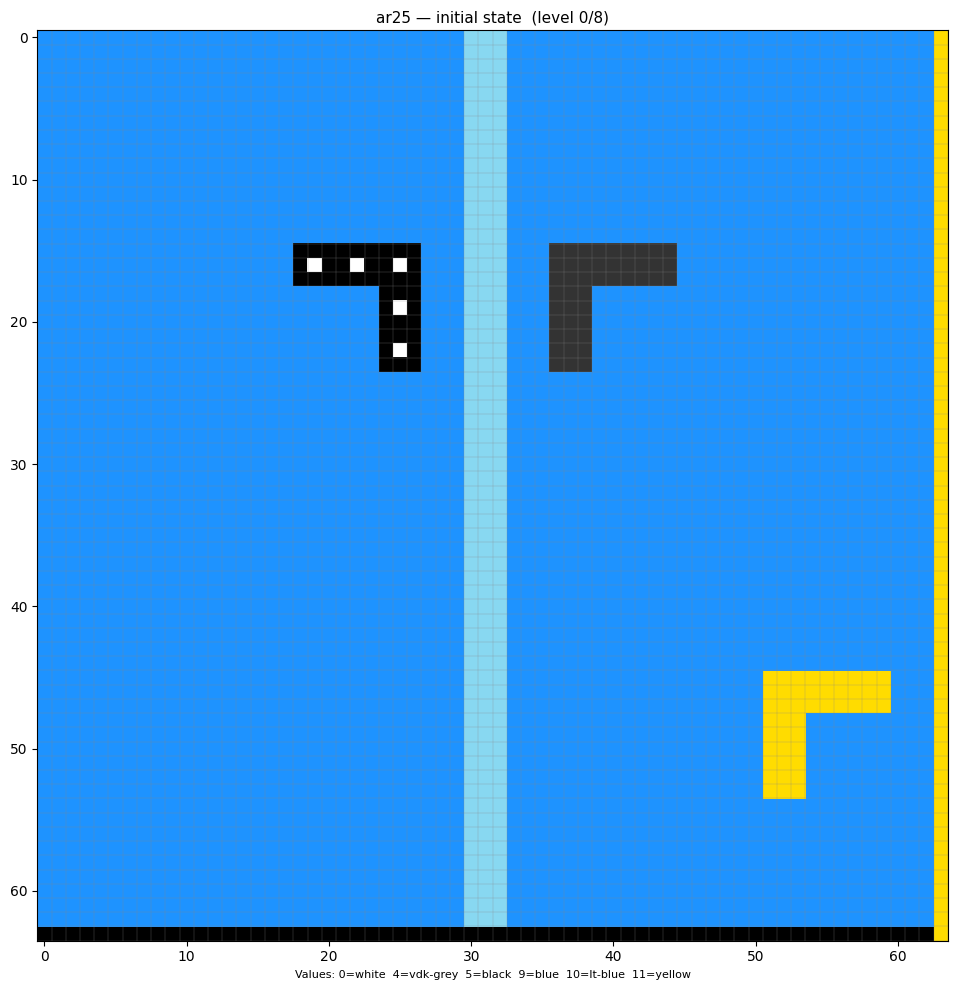

In [43]:
# ── Cell 2: Load a game ───────────────────────────────────────────────────────
GAME = 'ar25'

_game_id = GAME
_env = _arcade.make(GAME)
obs = _env.observation_space
_last_grid = [row.tolist() for row in obs.frame[-1]]
_last_levels = obs.levels_completed

print(f'Loaded: {GAME}')
print(f'Win condition: complete {obs.win_levels} levels')
baseline = _env.info.baseline_actions
print(f'Baseline human actions per level: {baseline}')
print(f'Frame layers: {len(obs.frame)}')
print()
print_frame_info(obs, action_taken='(initial state / RESET)')

show_grid(_last_grid, title=f'{GAME} — initial state  (level 0/{obs.win_levels})')


Action taken:      ACTION1 (ACTION1)
State:             NOT_FINISHED
Levels completed:  0 / 8
Full reset:        False
Available actions: [1, 2, 3, 4, 5, 6, 7]



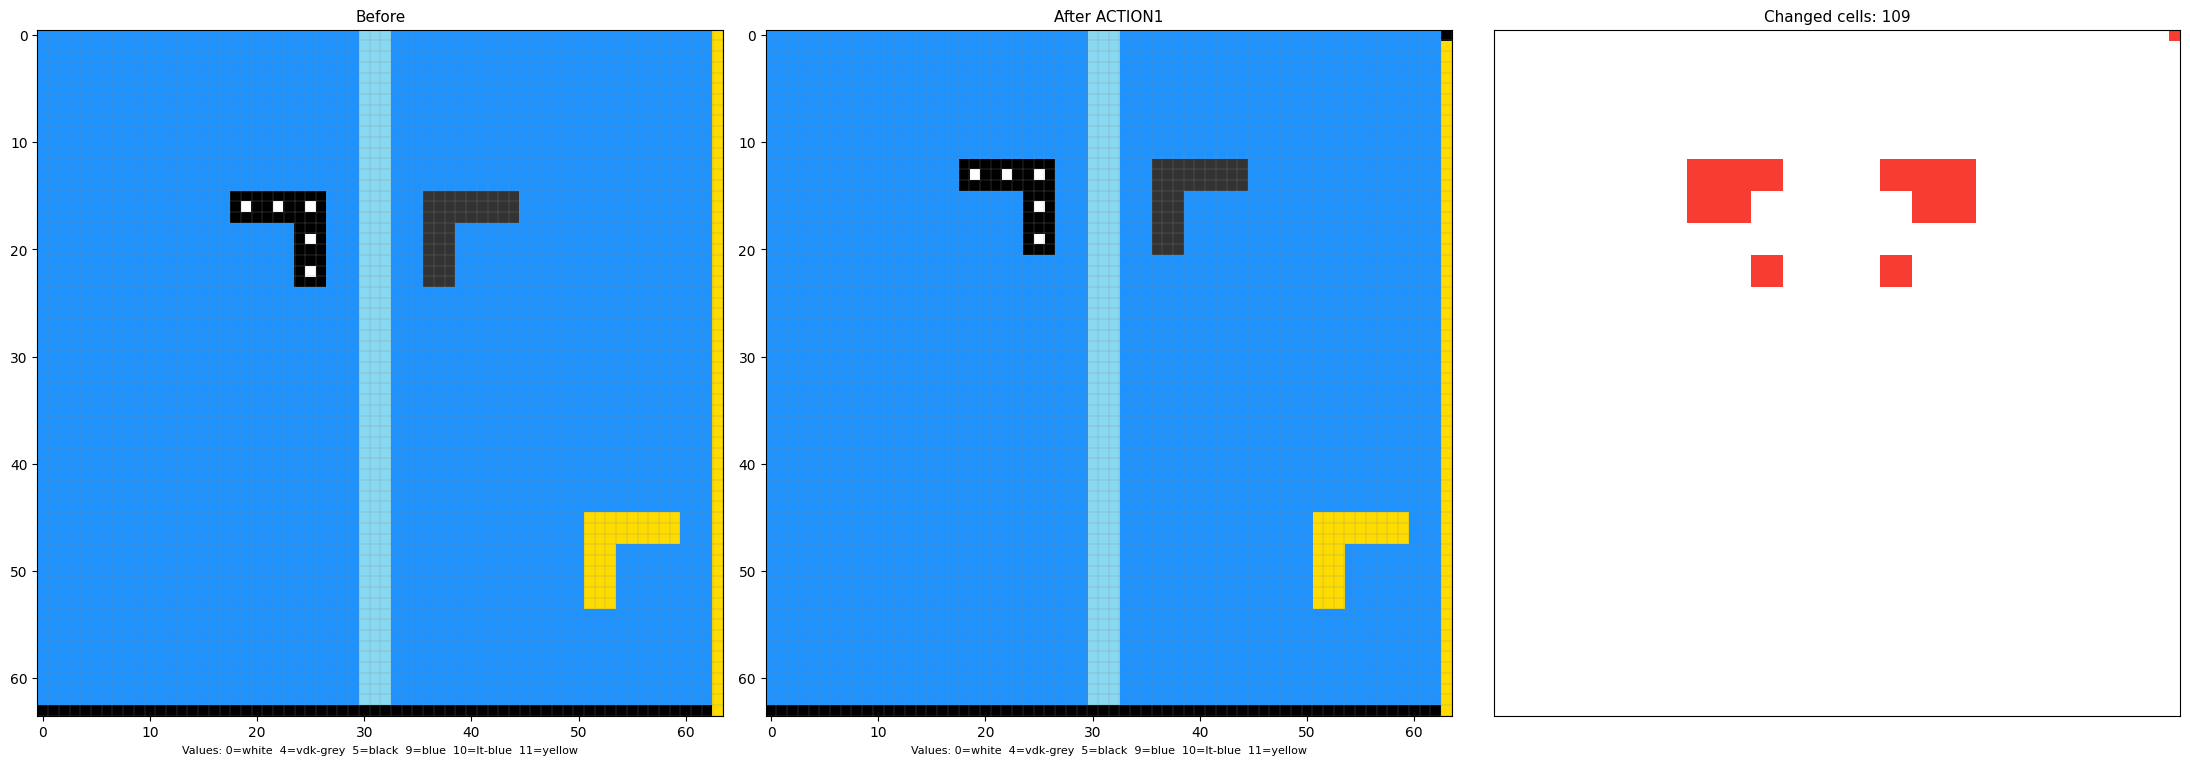

In [34]:
# ── Cell 3: Take one action ───────────────────────────────────────────────────
# Change ACTION to: 'reset', '1', '2', '3', '4', '5', '6', or '7'
ACTION = '1'

if _env is None:
    print('Run Cell 2 first to load a game.')
else:
    grid_before = _last_grid
    action = ACTION_NAMES[ACTION]
    frame = _env.step(action, data={})
    grid_after = [row.tolist() for row in frame.frame[-1]]
    _last_grid = grid_after
    _last_levels = frame.levels_completed

    print_frame_info(frame, action_taken=f'ACTION{ACTION} ({action.name})')
    print()

    show_diff(grid_before, grid_after,
              title_before='Before',
              title_after=f'After ACTION{ACTION}')


2026-06-10 15:15:16 | INFO | Found latest version of ar25: ar25-0c556536 (downloaded: 2026-04-08 20:07:48.460282+00:00)
Reset ar25.
State:             NOT_FINISHED
Levels completed:  0 / 8
Full reset:        True
Available actions: [1, 2, 3, 4, 5, 6, 7]


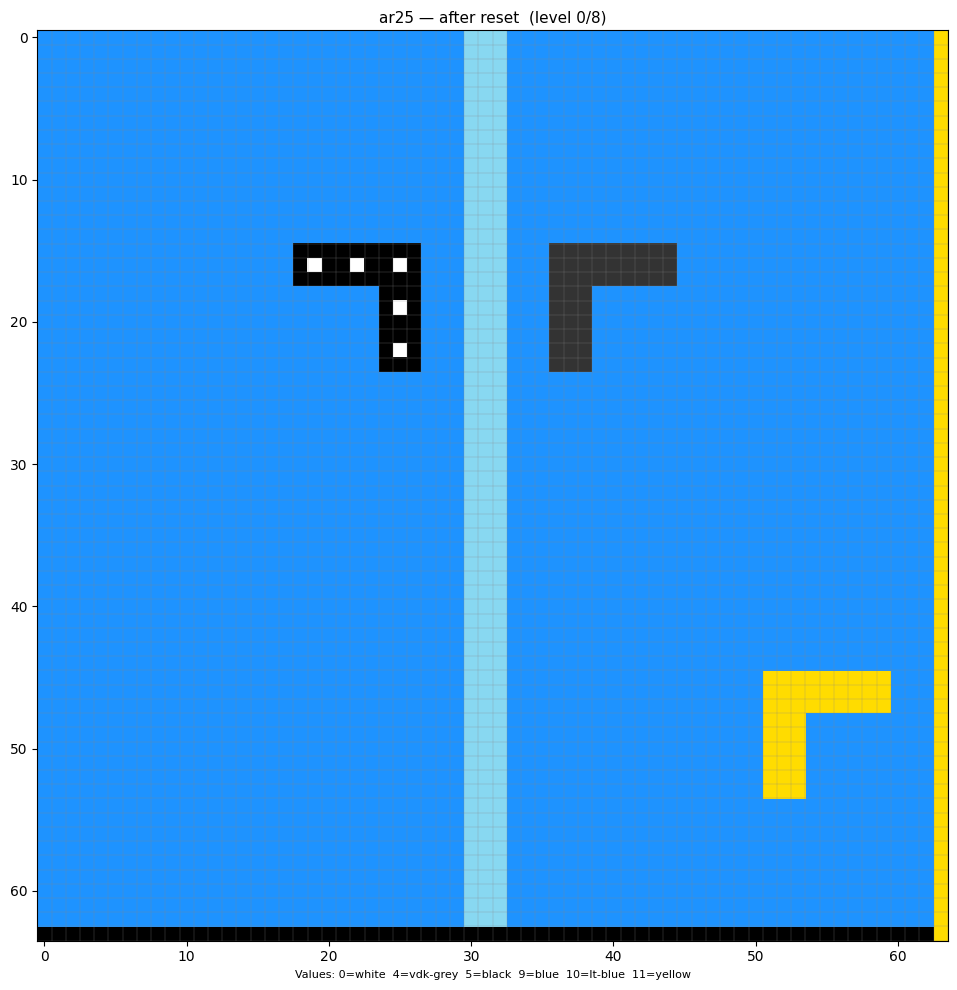

In [45]:
# ── Cell 4: Reset the game ────────────────────────────────────────────────────
if _game_id is None:
    print('Run Cell 2 first to load a game.')
else:
    _env = _arcade.make(_game_id)
    obs = _env.observation_space
    _last_grid = [row.tolist() for row in obs.frame[-1]]
    _last_levels = obs.levels_completed
    print(f'Reset {_game_id}.')
    print_frame_info(obs)
    show_grid(_last_grid, title=f'{_game_id} — after reset  (level 0/{obs.win_levels})')


In [46]:
# ── Cell 5: Survey all games ──────────────────────────────────────────────────
print(f'{"Game":<8}  {"Win levels":<12}  {"Baseline actions":<18}  Available action IDs')
print('-' * 65)
for env_info in sorted(_arcade.available_environments, key=lambda e: e.game_id):
    gid = env_info.game_id.split('-')[0]
    env = _arcade.make(gid)
    if env is None:
        continue
    obs = env.observation_space
    baseline = env_info.baseline_actions or []
    print(f'{gid:<8}  {obs.win_levels:<12}  {len(baseline):<18}  {obs.available_actions}')


Game      Win levels    Baseline actions    Available action IDs
-----------------------------------------------------------------
2026-06-10 15:15:17 | INFO | Found latest version of ar25: ar25-0c556536 (downloaded: 2026-04-08 20:07:48.460282+00:00)
ar25      8             8                   [1, 2, 3, 4, 5, 6, 7]
2026-06-10 15:15:17 | INFO | Found latest version of bp35: bp35-0a0ad940 (downloaded: 2026-04-08 20:07:48.891045+00:00)
bp35      9             9                   [3, 4, 6, 7]
2026-06-10 15:15:17 | INFO | Found latest version of cd82: cd82-fb555c5d (downloaded: 2026-04-08 20:07:49.045128+00:00)
cd82      6             6                   [1, 2, 3, 4, 5, 6]
2026-06-10 15:15:17 | INFO | Found latest version of cn04: cn04-2fe56bfb (downloaded: 2026-04-08 20:07:49.199835+00:00)
cn04      6             6                   [1, 2, 3, 4, 5, 6]
2026-06-10 15:15:17 | INFO | Found latest version of dc22: dc22-fdcac232 (downloaded: 2026-04-08 20:07:48.341428+00:00)
dc22      6         

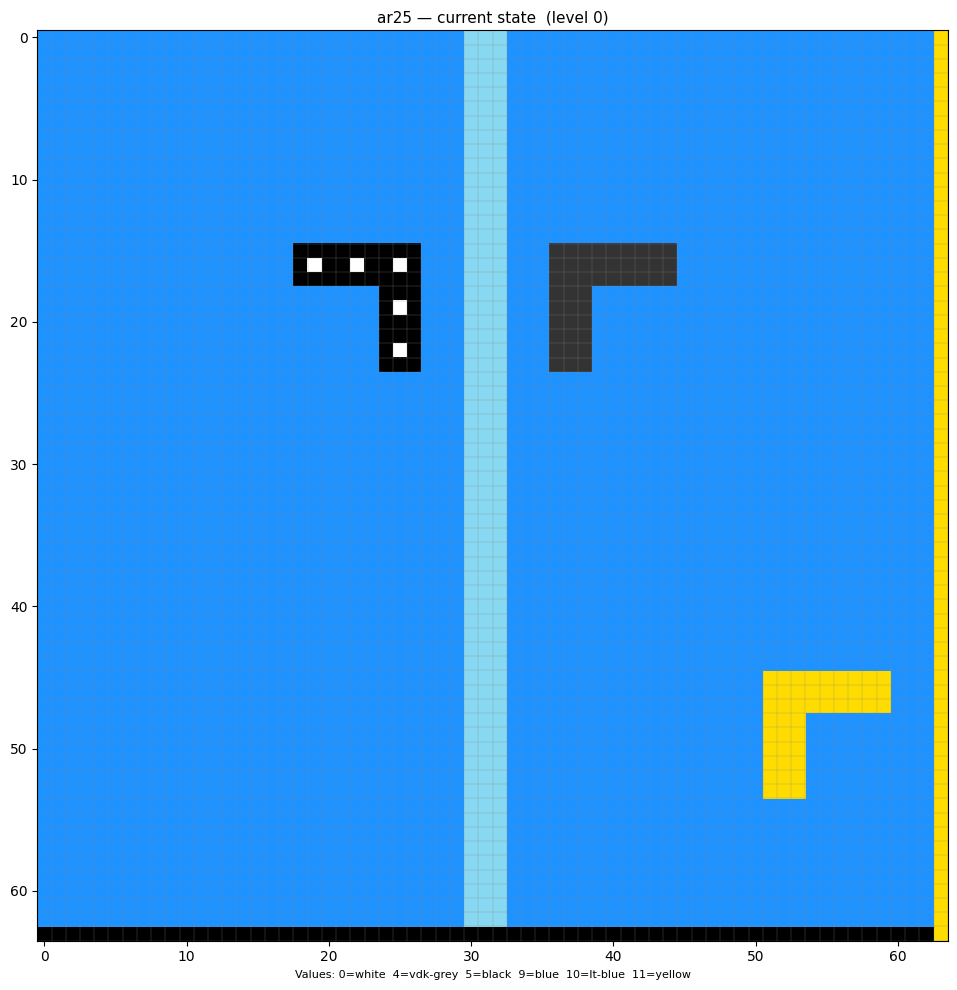

In [47]:
# ── Cell 6: Show current grid (without taking an action) ─────────────────────
if _last_grid is None:
    print('Run Cell 2 first.')
else:
    show_grid(_last_grid, title=f'{_game_id} — current state  (level {_last_levels})')


Continuing ar25 from level 0. Win at 8.
Baseline per level: [32, 50, 75, 37, 89, 159, 233, 73]

Step  1: ACTION2  →  level 0/8


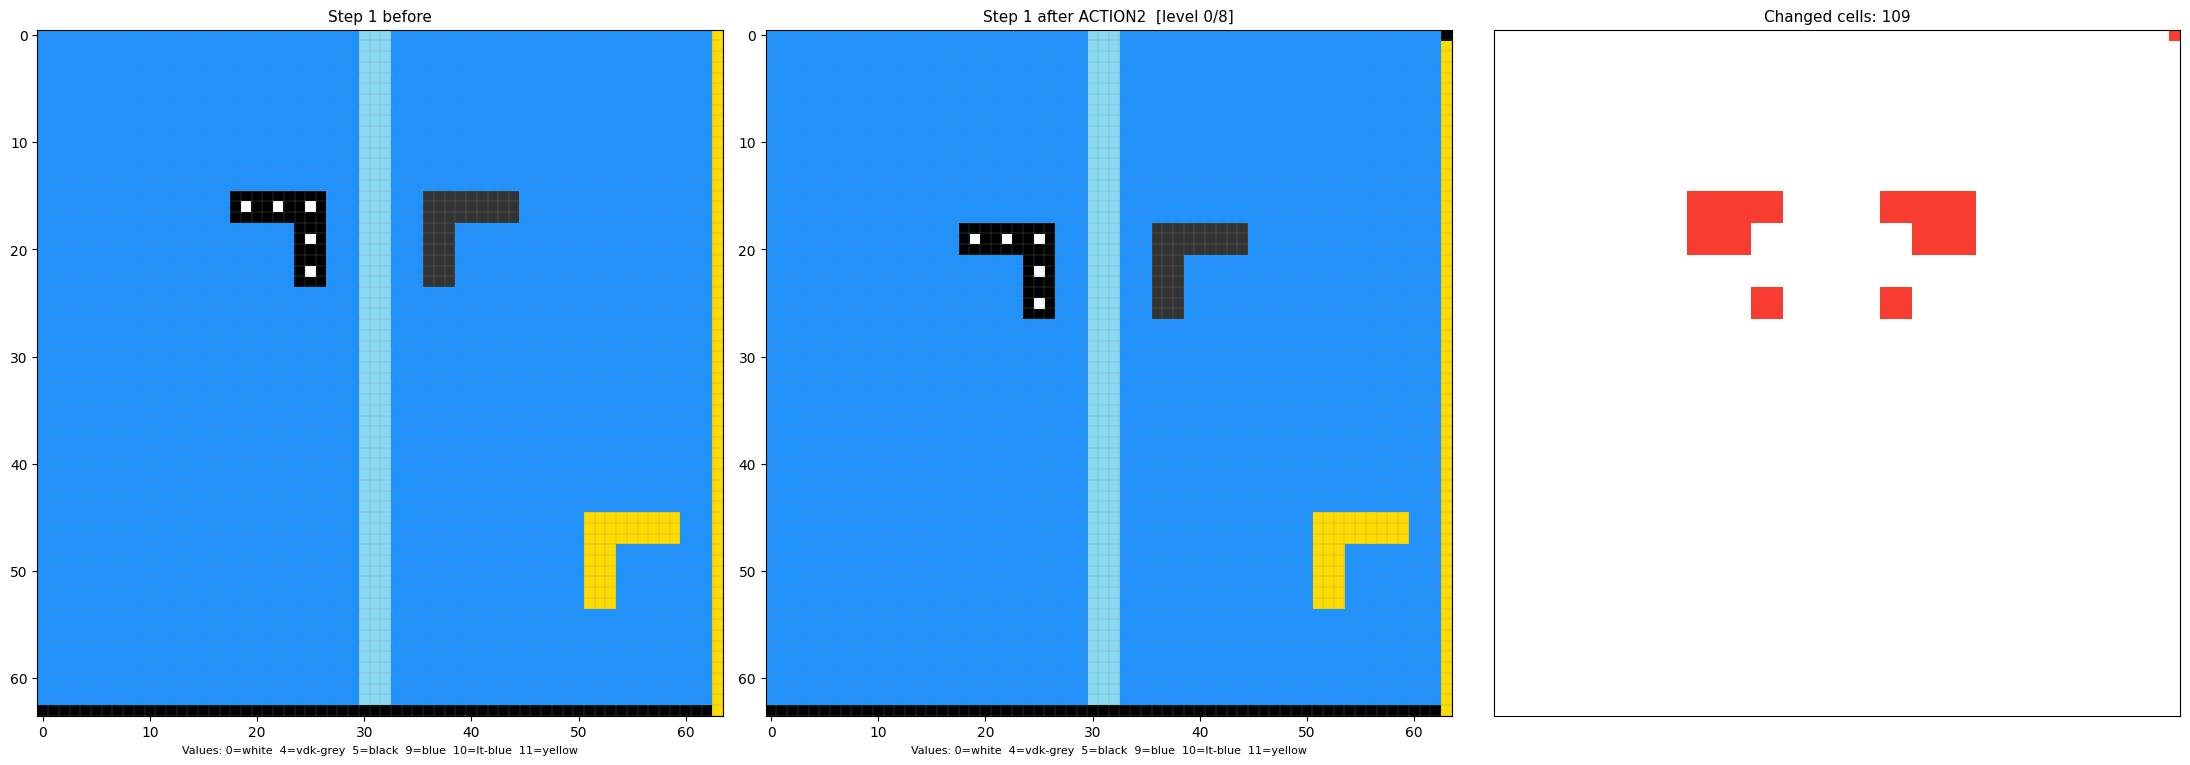

Step  2: ACTION2  →  level 0/8


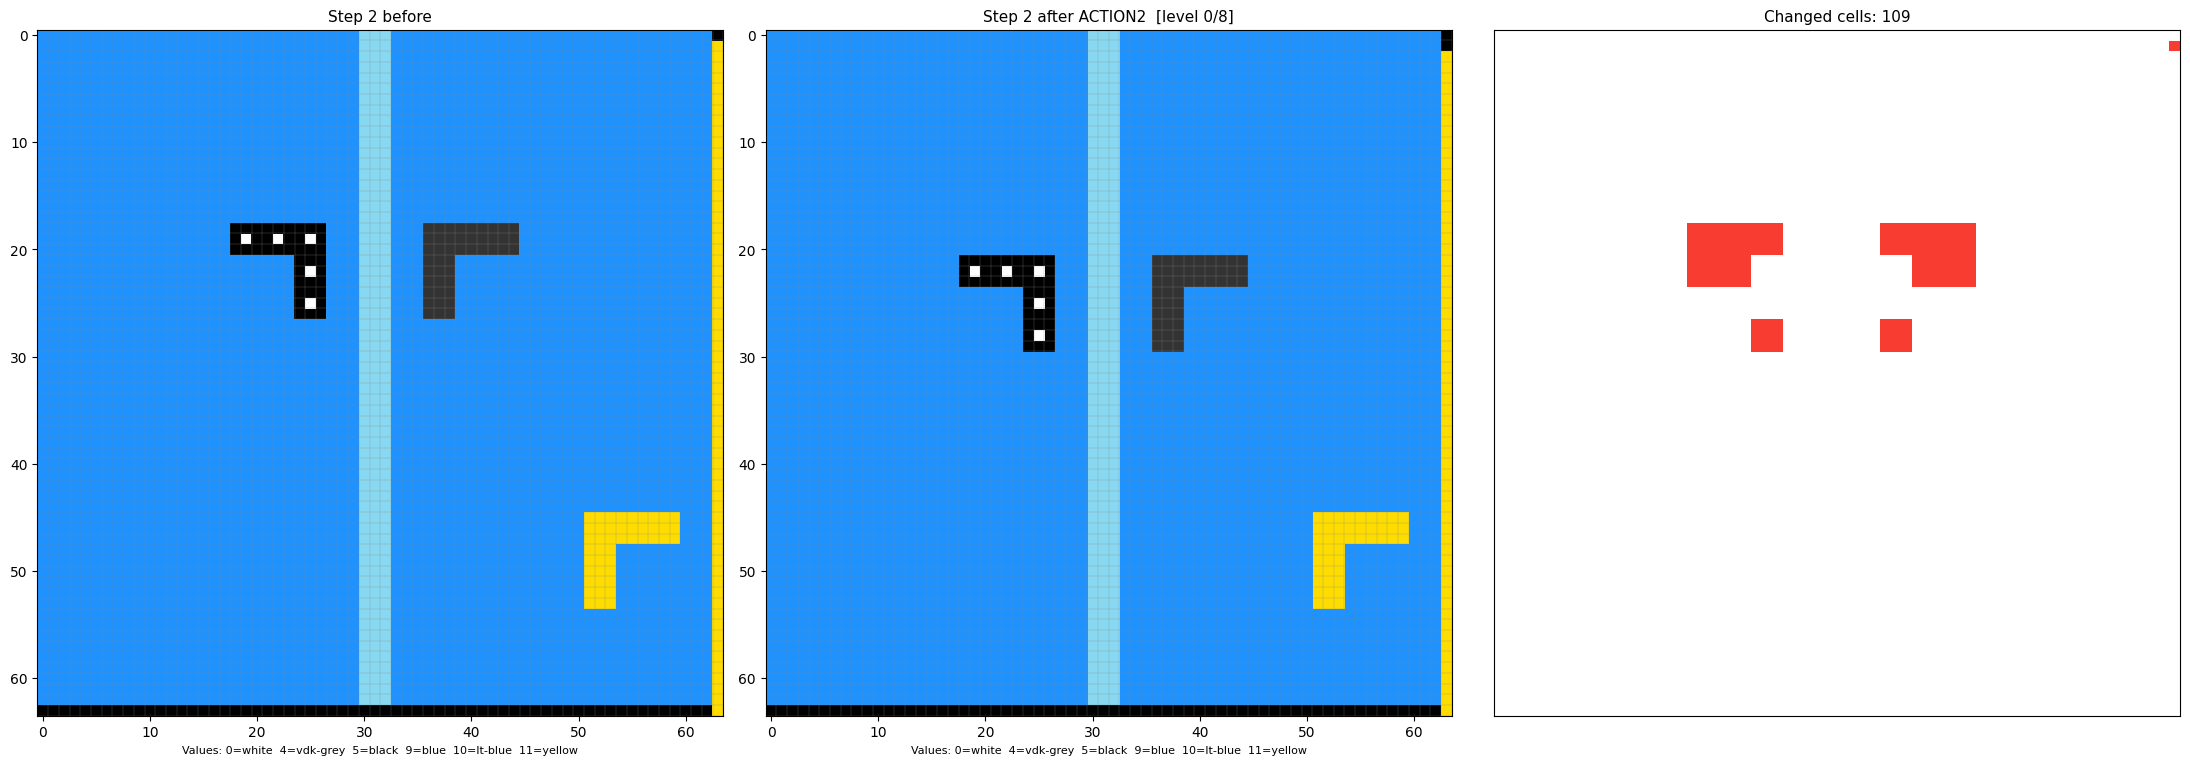

Step  3: ACTION2  →  level 0/8


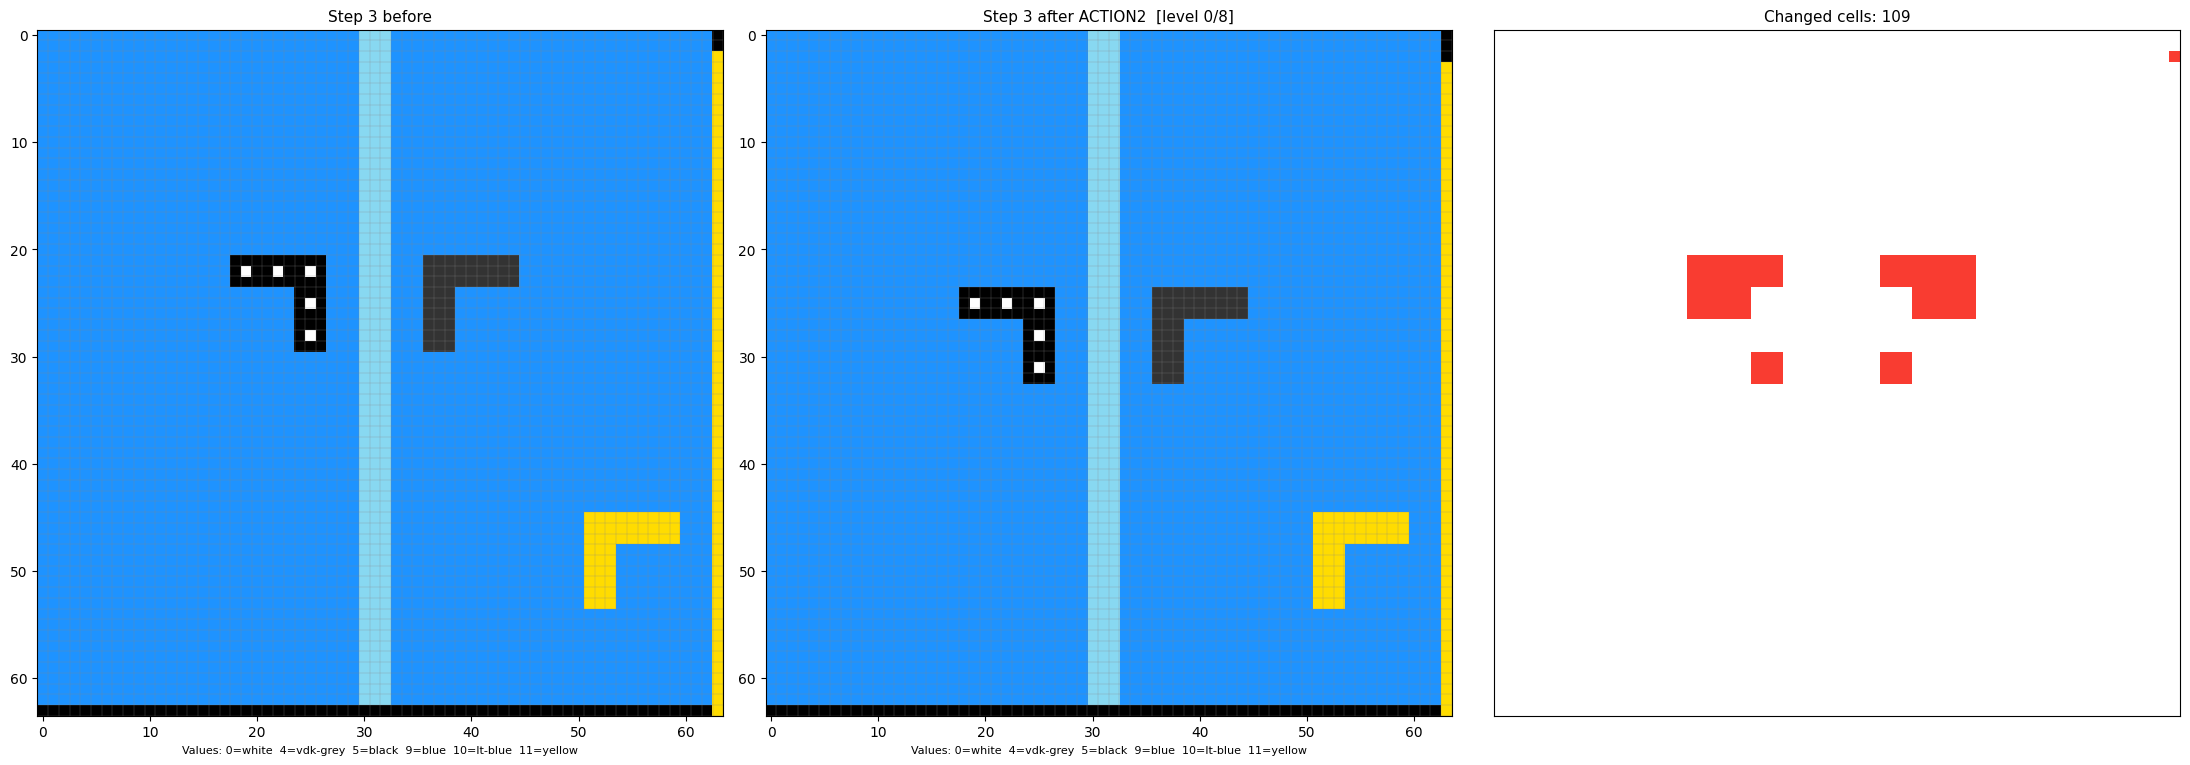

Step  4: ACTION2  →  level 0/8


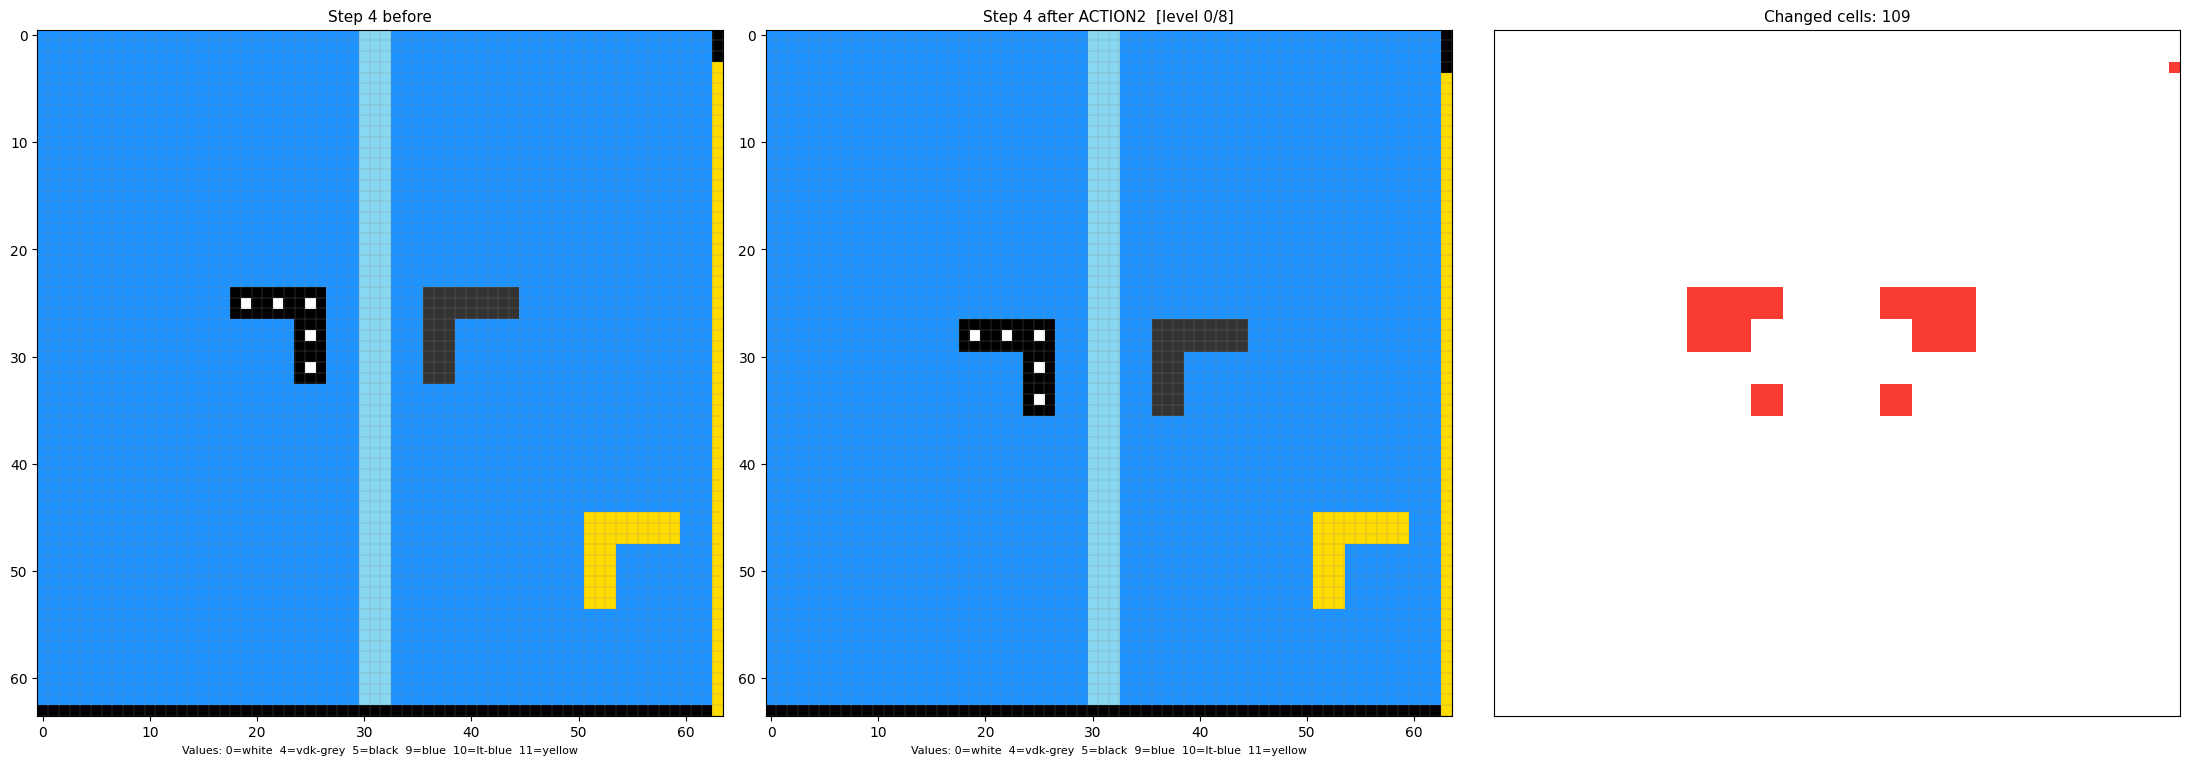

Step  5: ACTION2  →  level 0/8


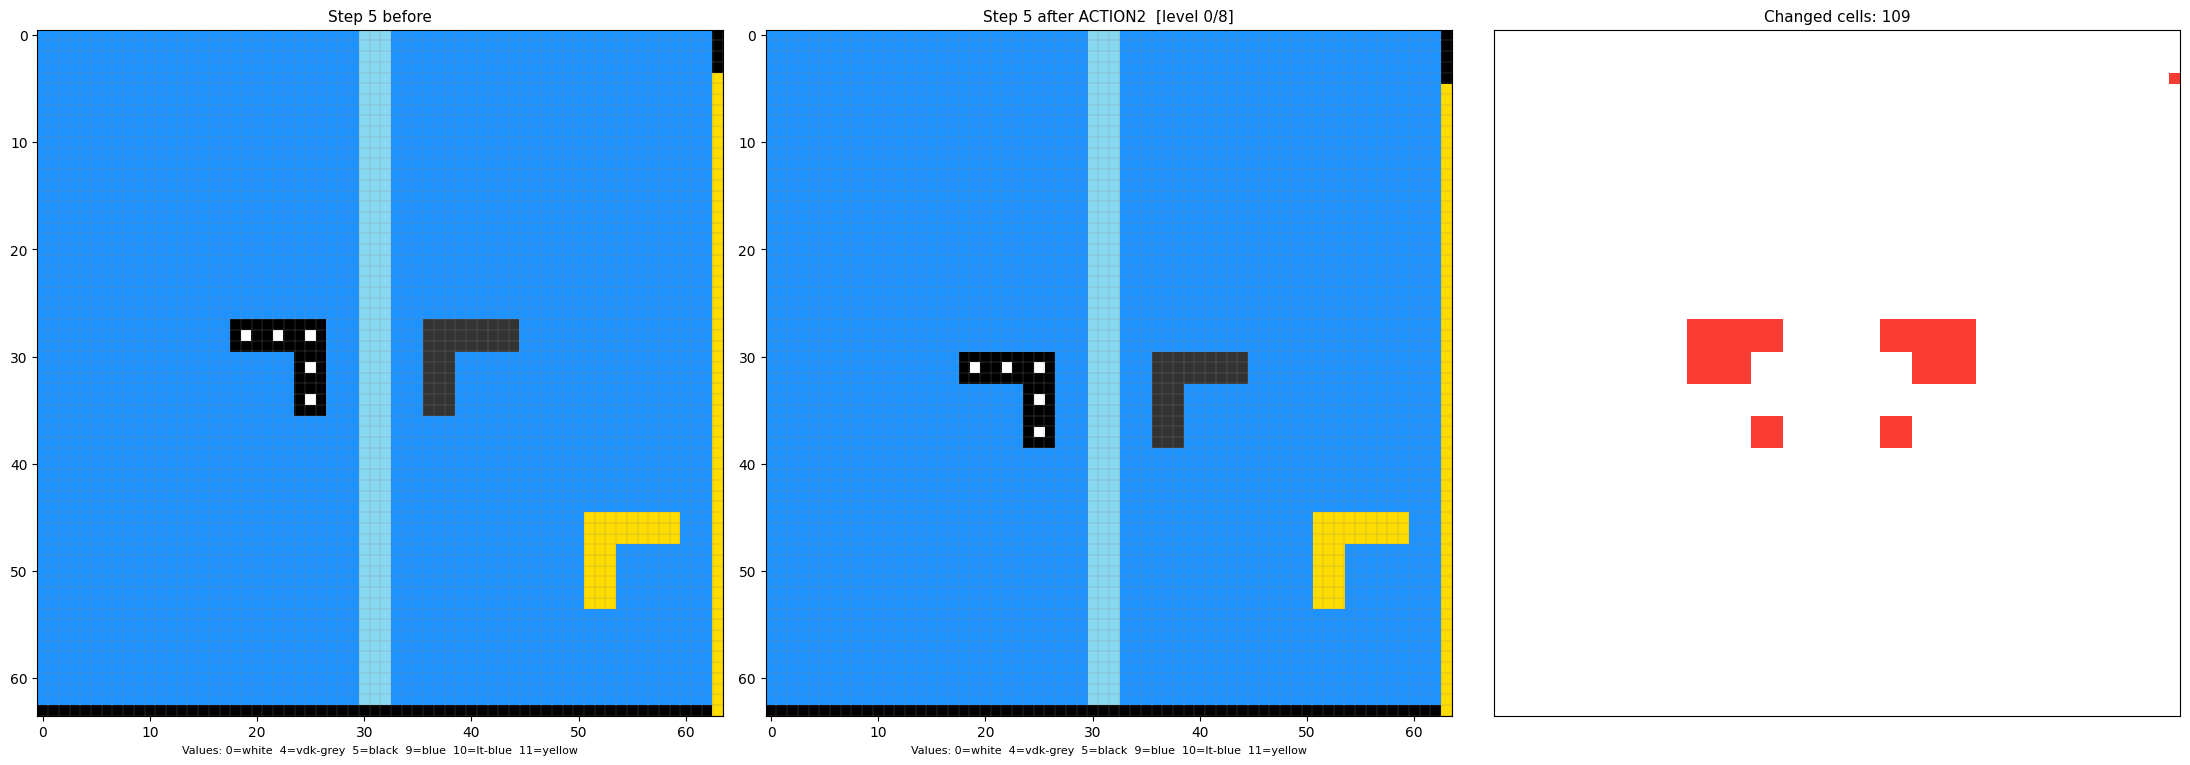

Step  6: ACTION2  →  level 0/8


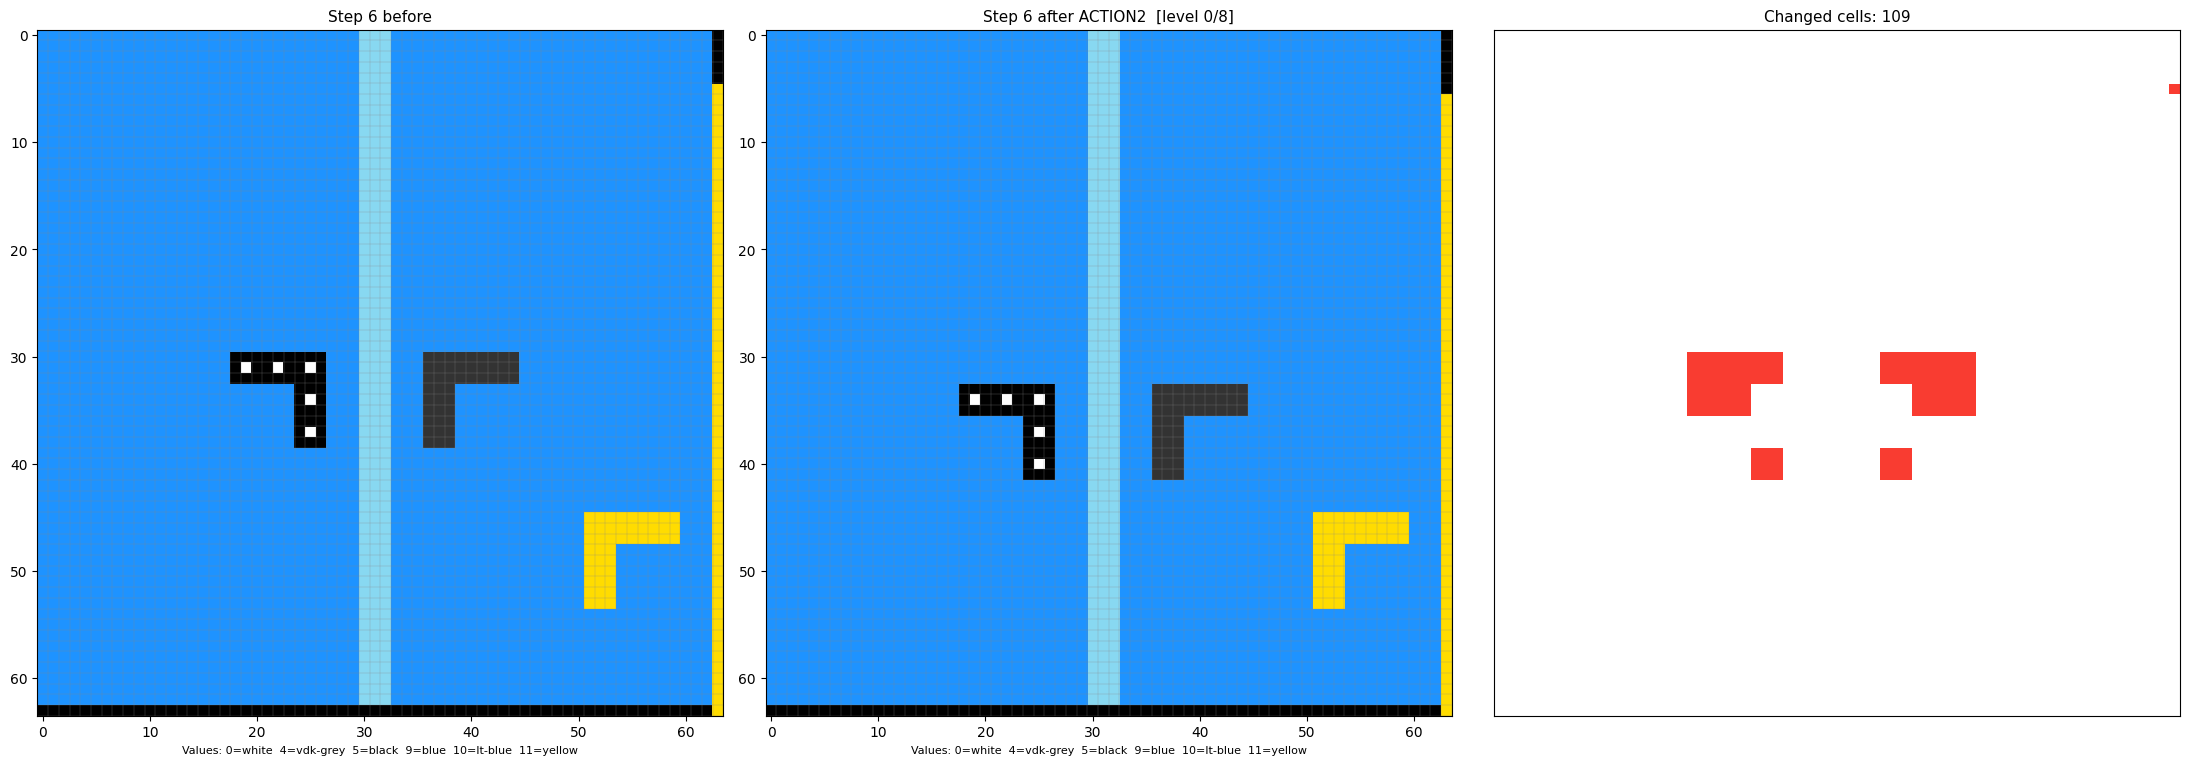

Step  7: ACTION3  →  level 0/8


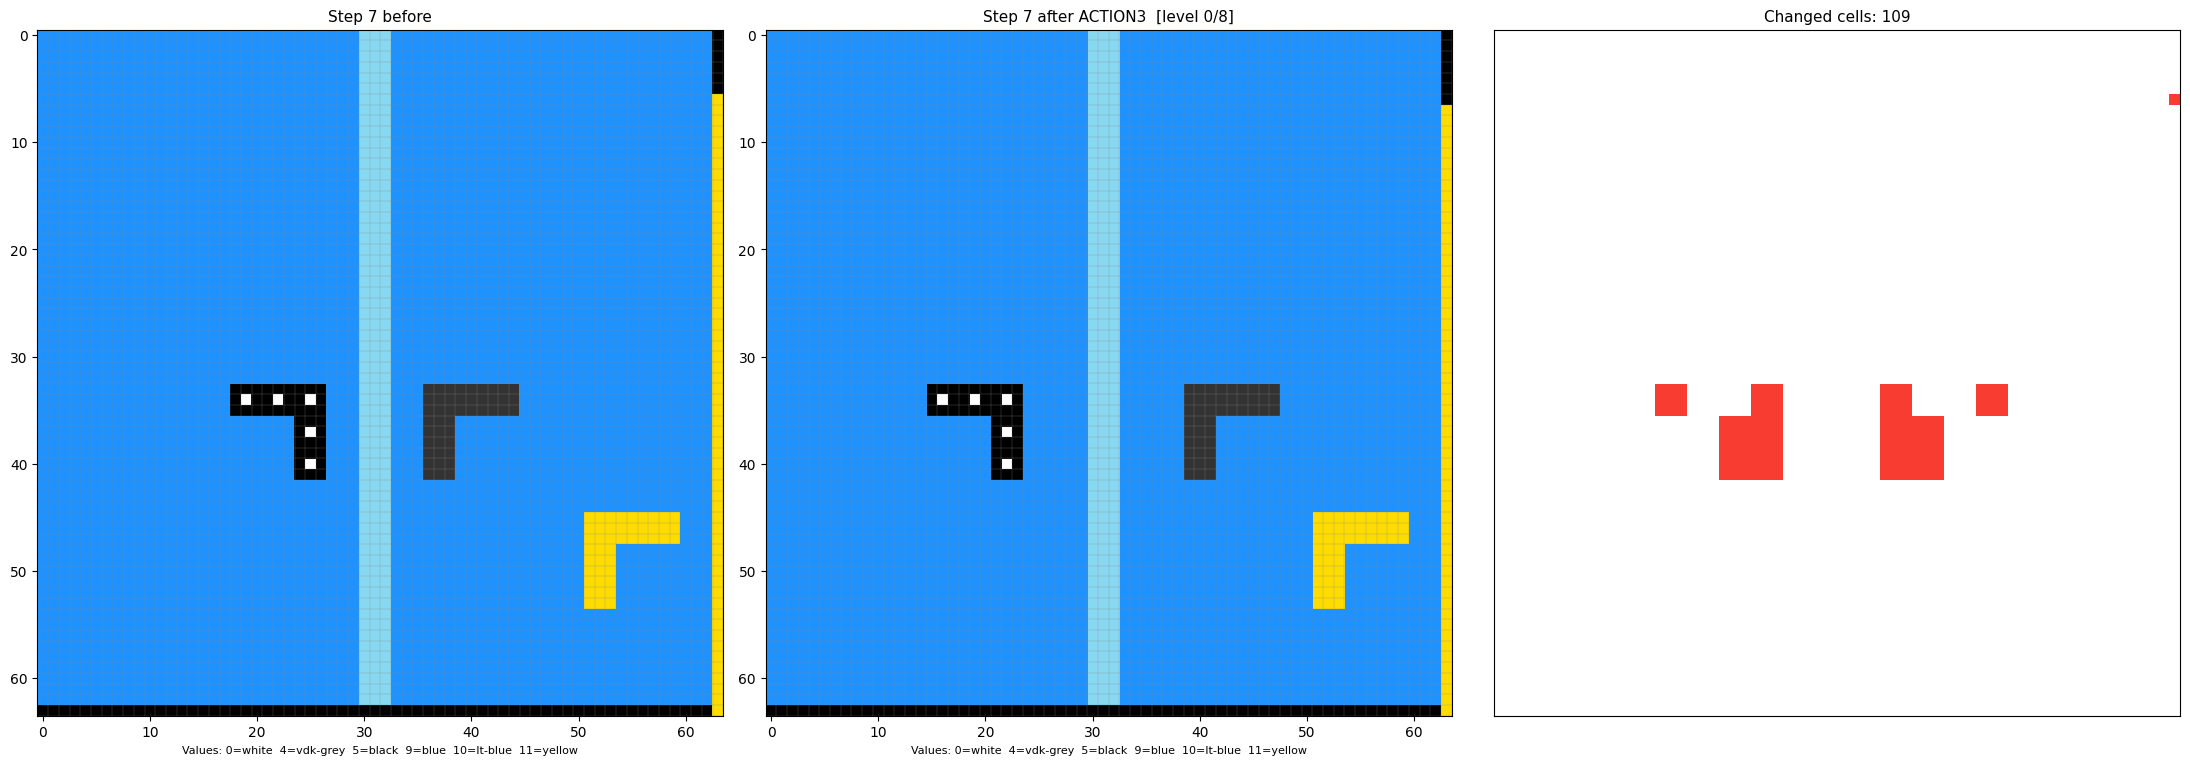

Step  8: ACTION3  →  level 0/8


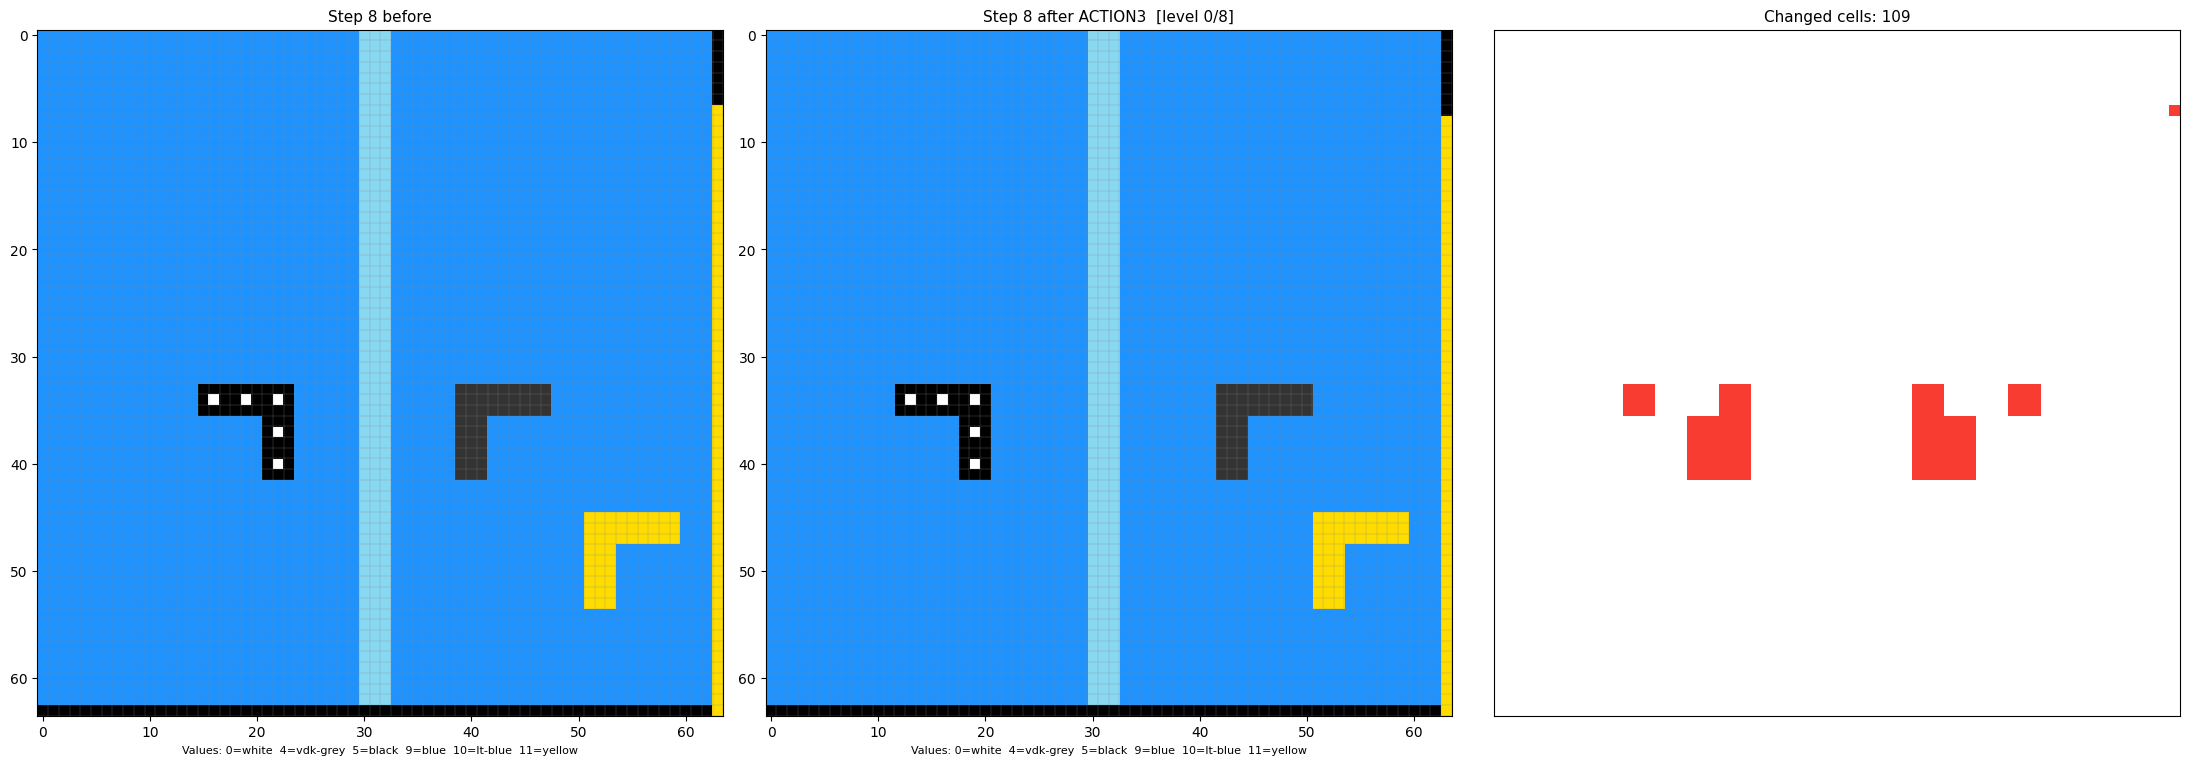

Step  9: ACTION3  →  level 0/8


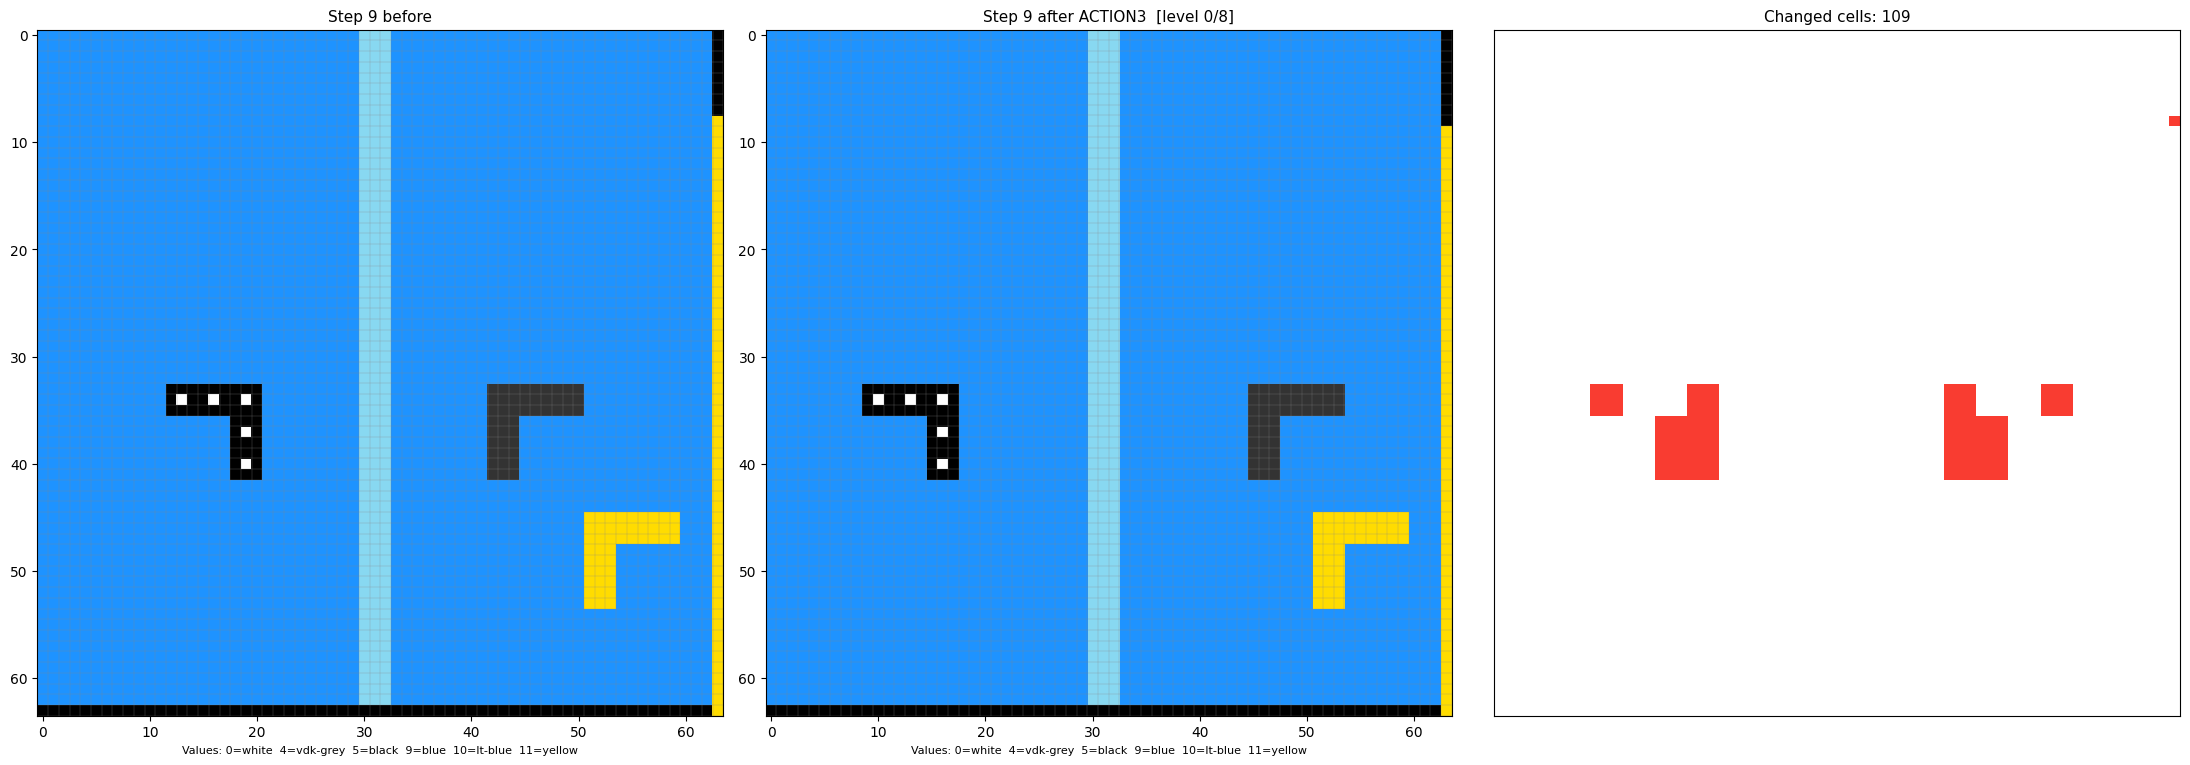

Step 10: ACTION3  →  level 0/8


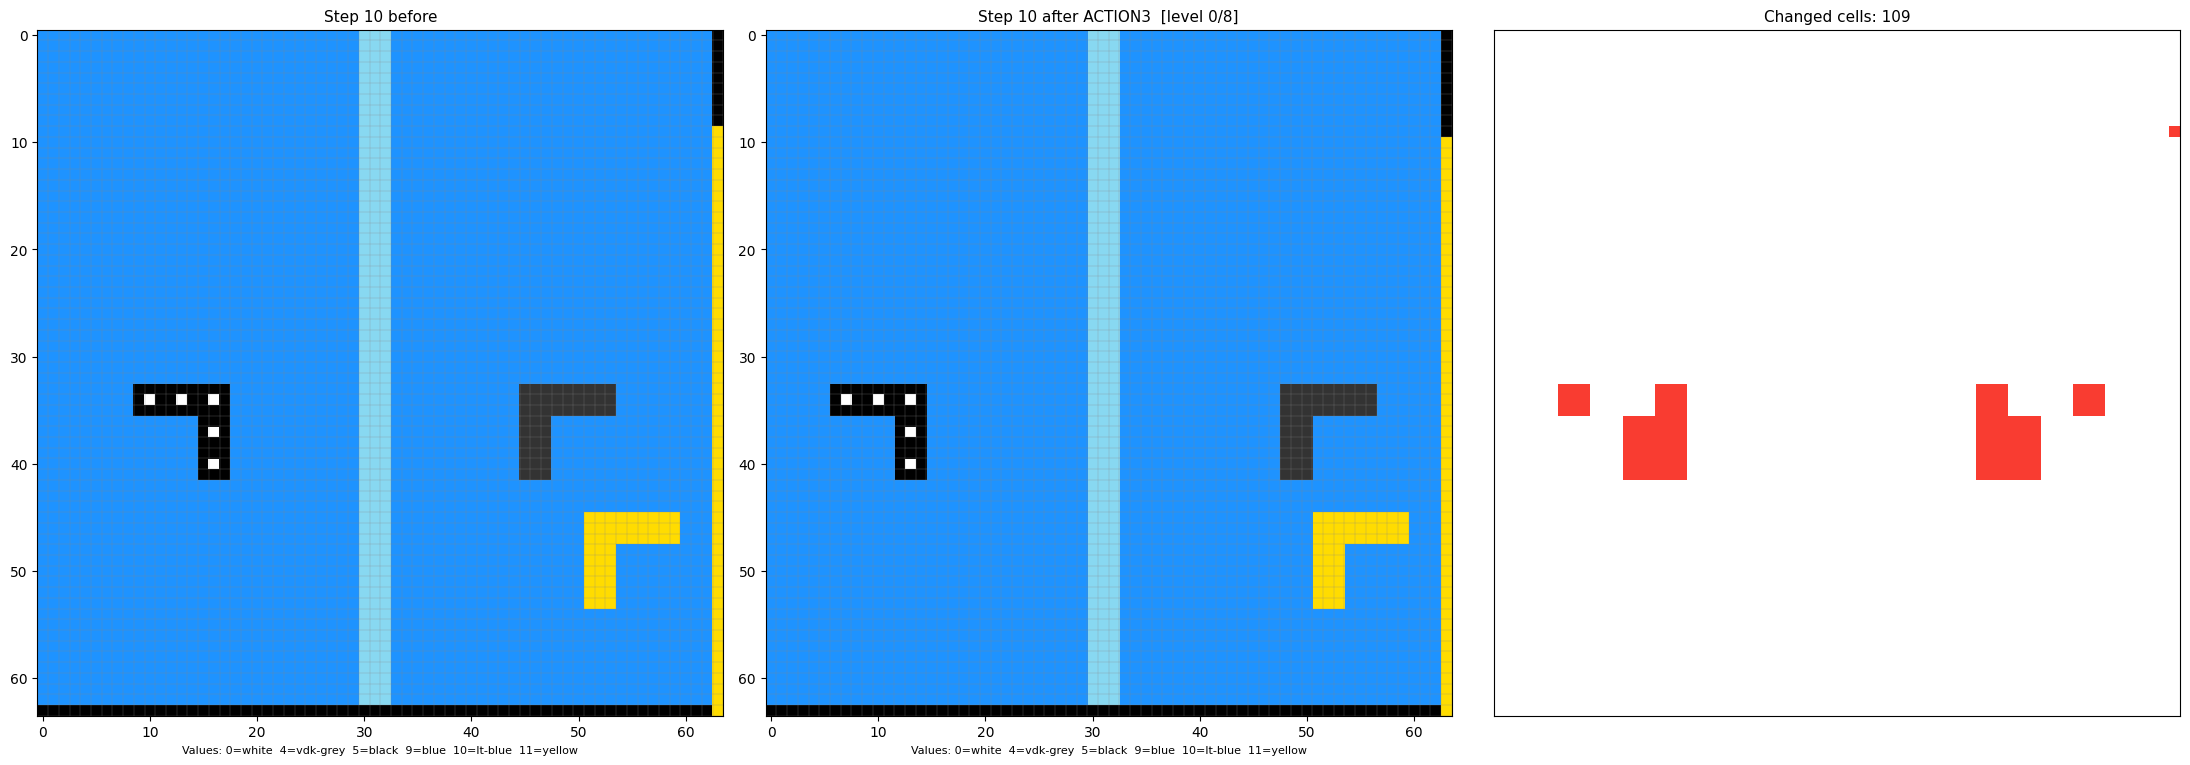

Step 11: ACTION3  →  level 0/8


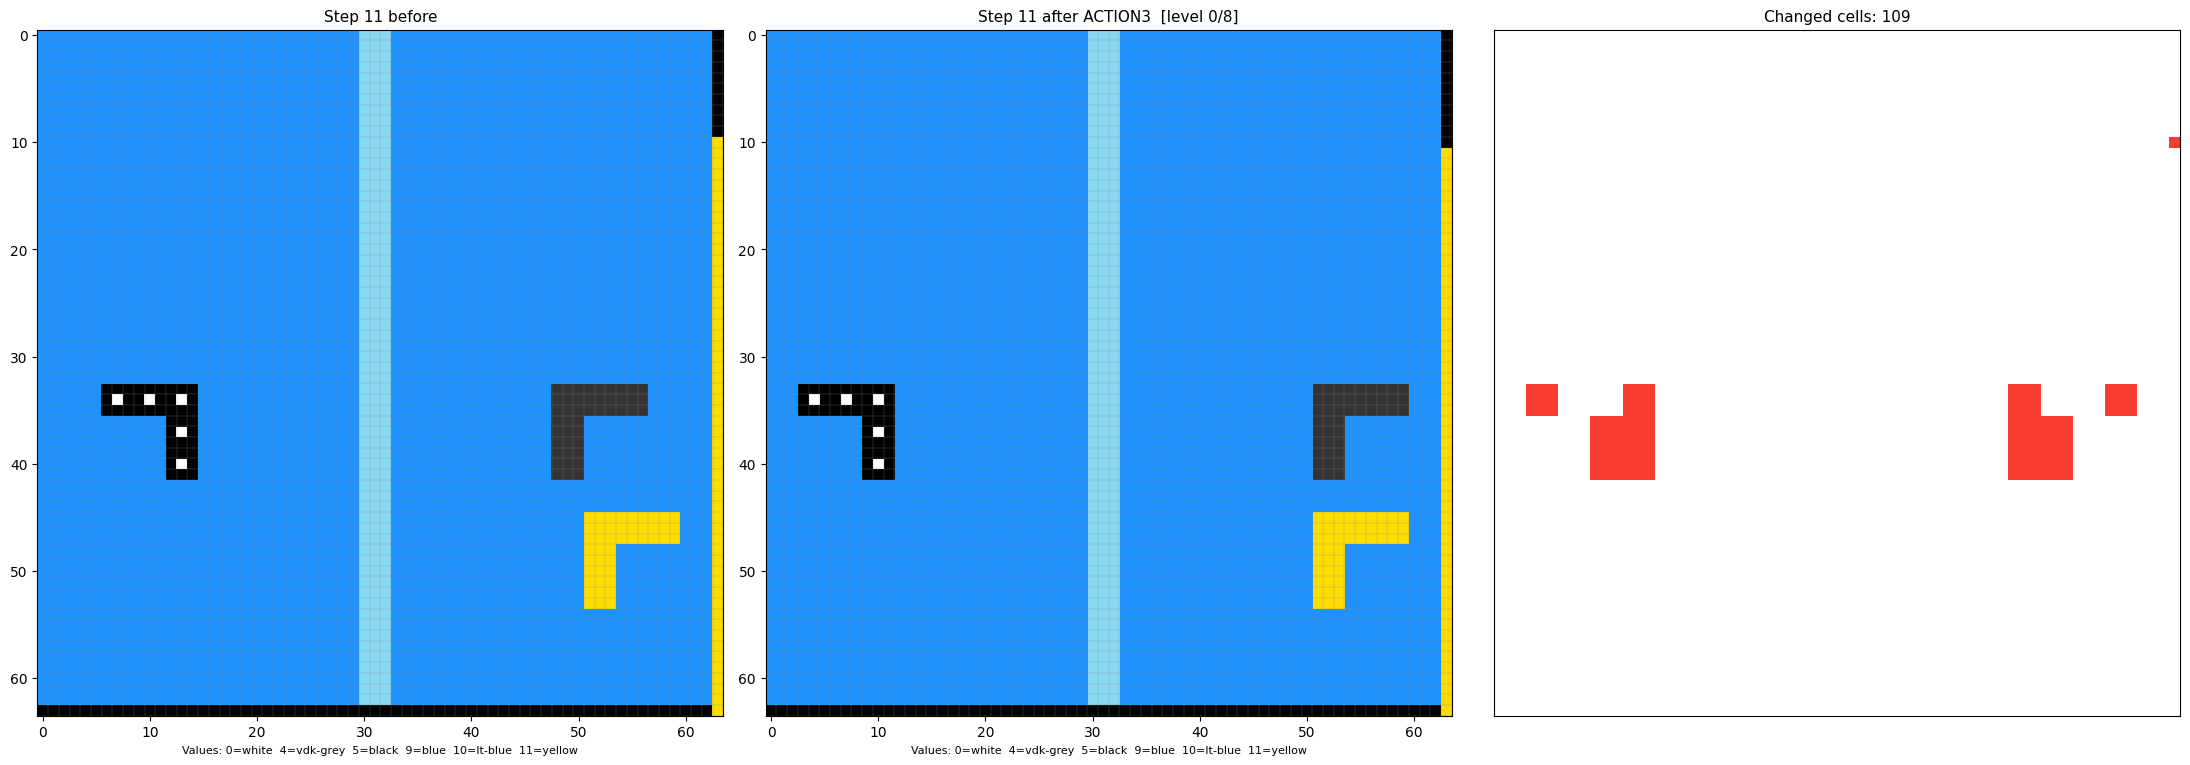

Step 12: ACTION2  →  level 0/8


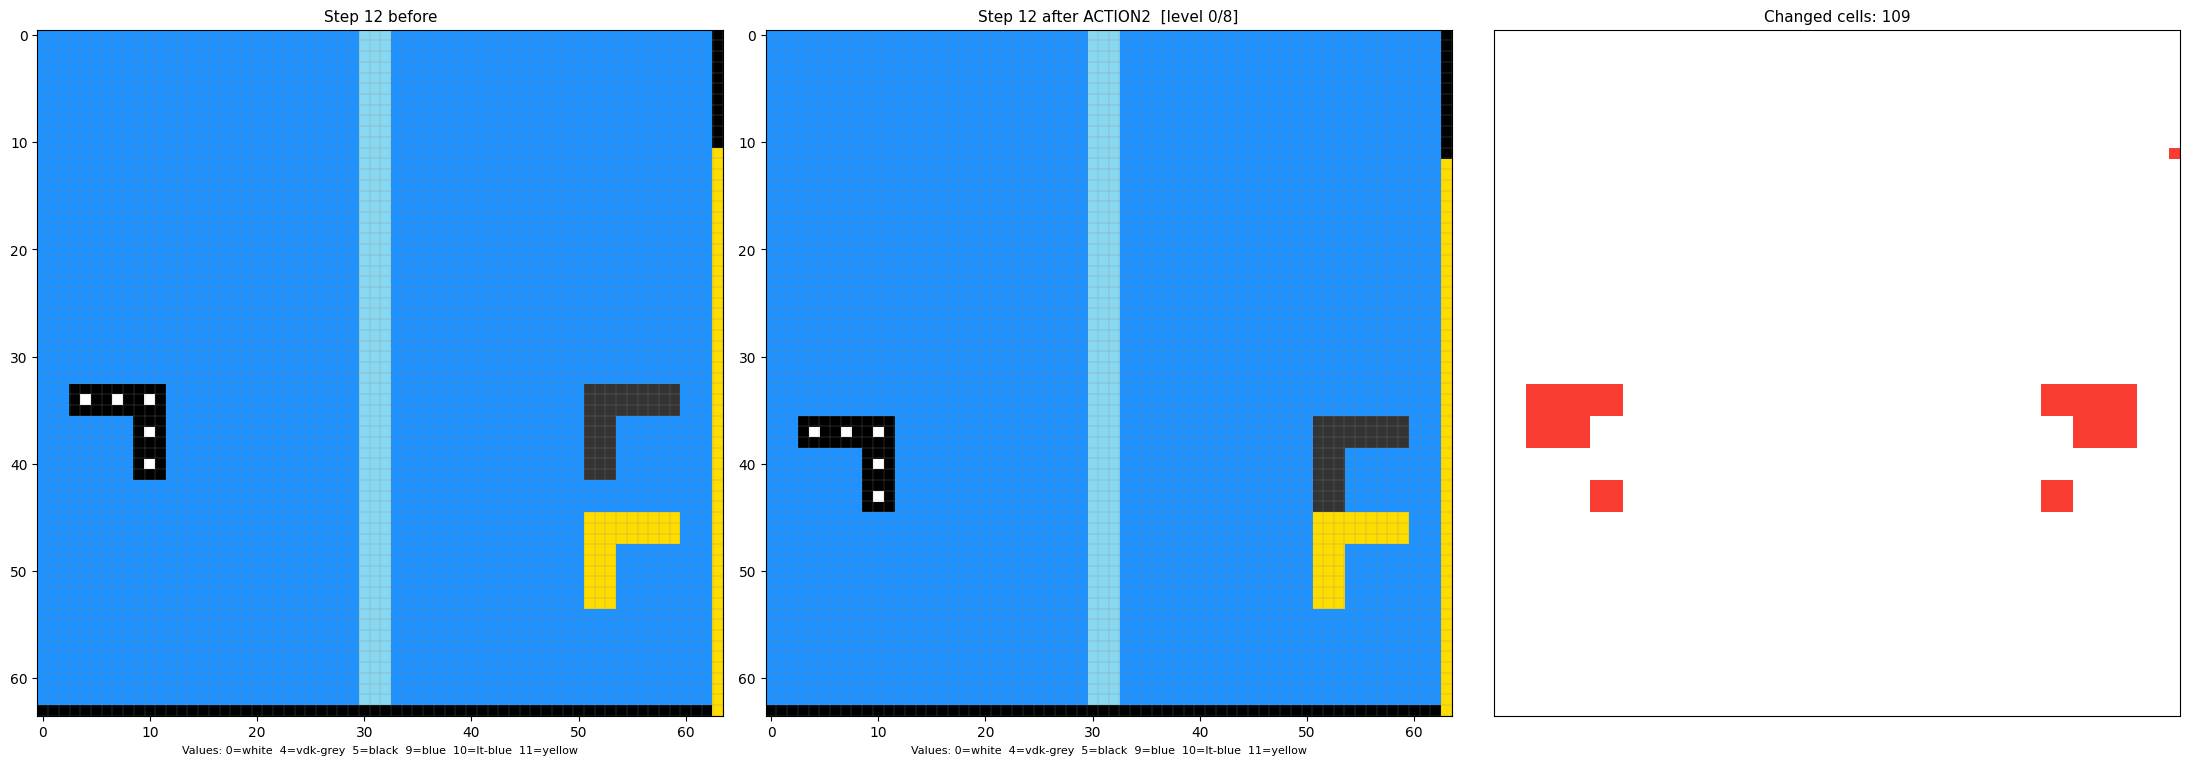

Step 13: ACTION2  →  level 0/8


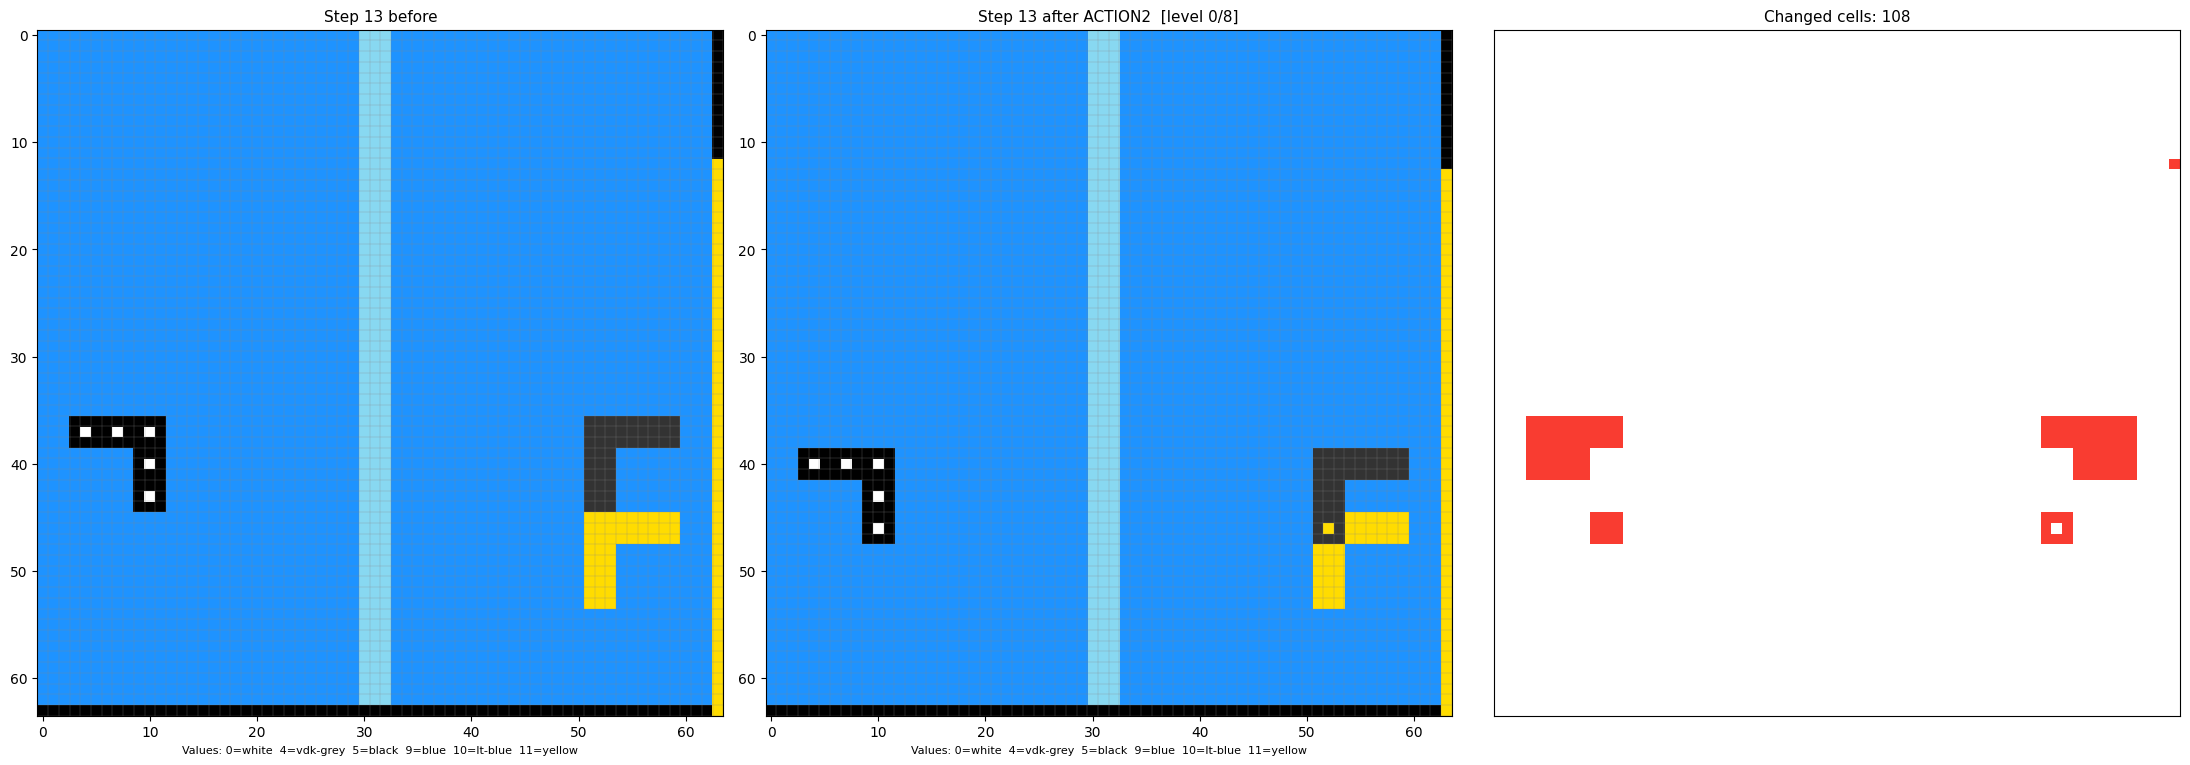

Step 14: ACTION2  →  level 0/8


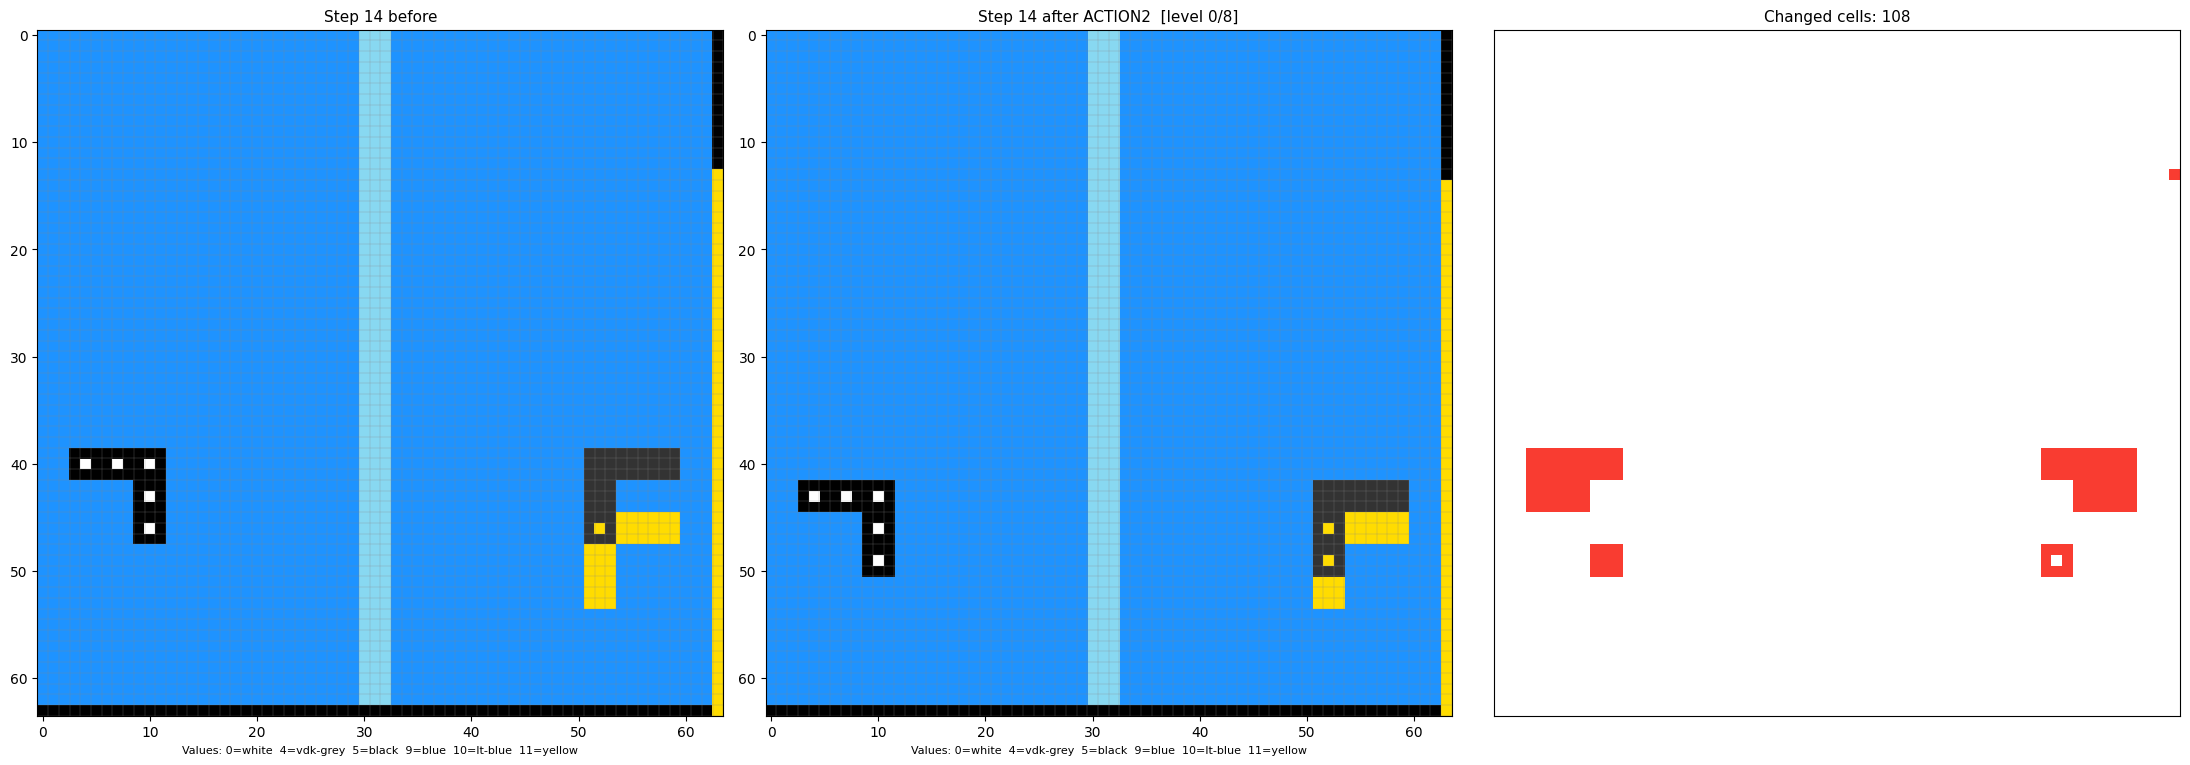

Step 15: ACTION2  →  ★ LEVEL 1 COMPLETE ★


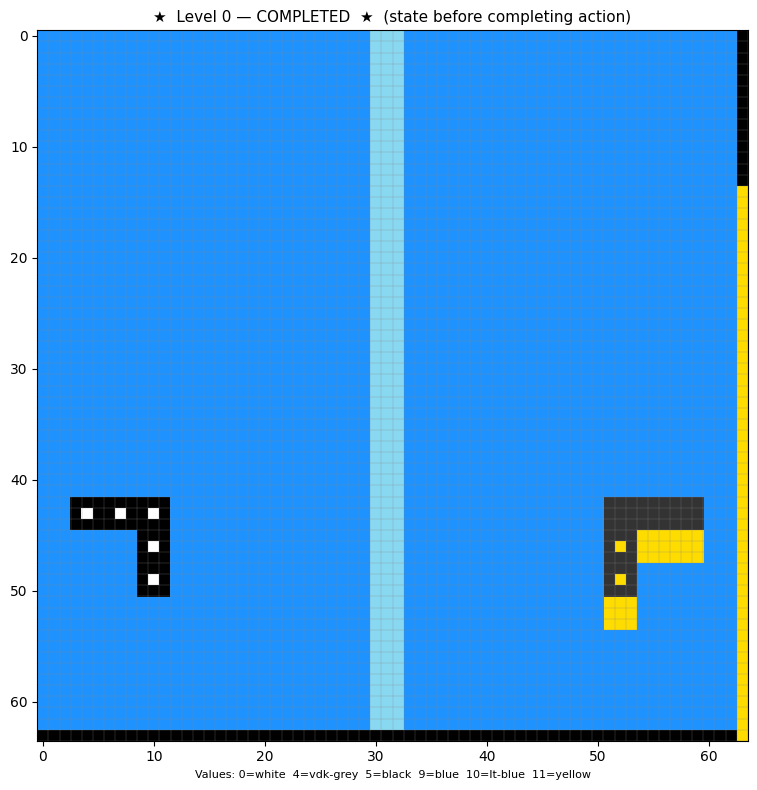

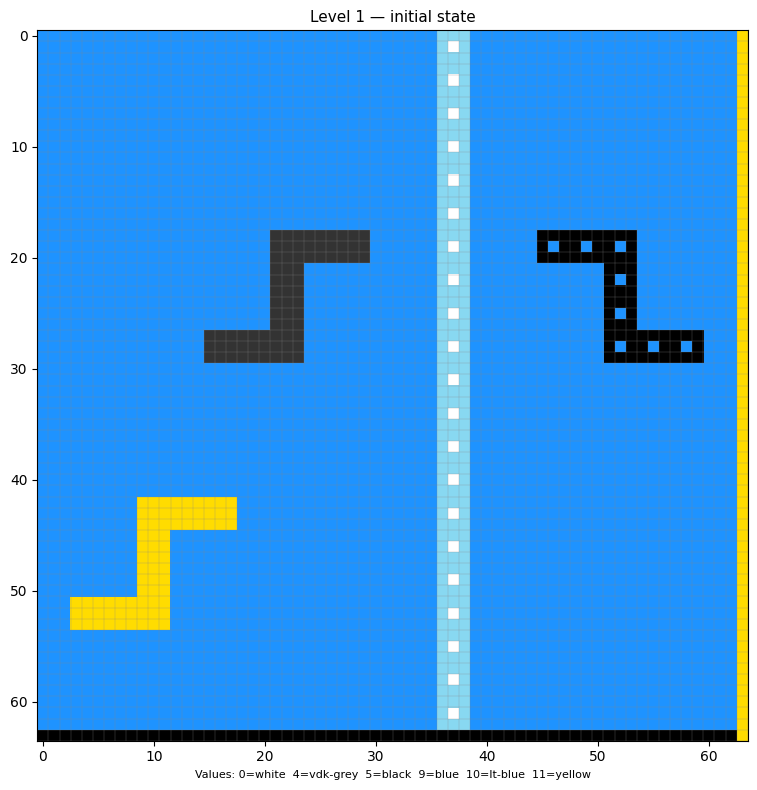

Step 16: ACTION1  →  level 1/8


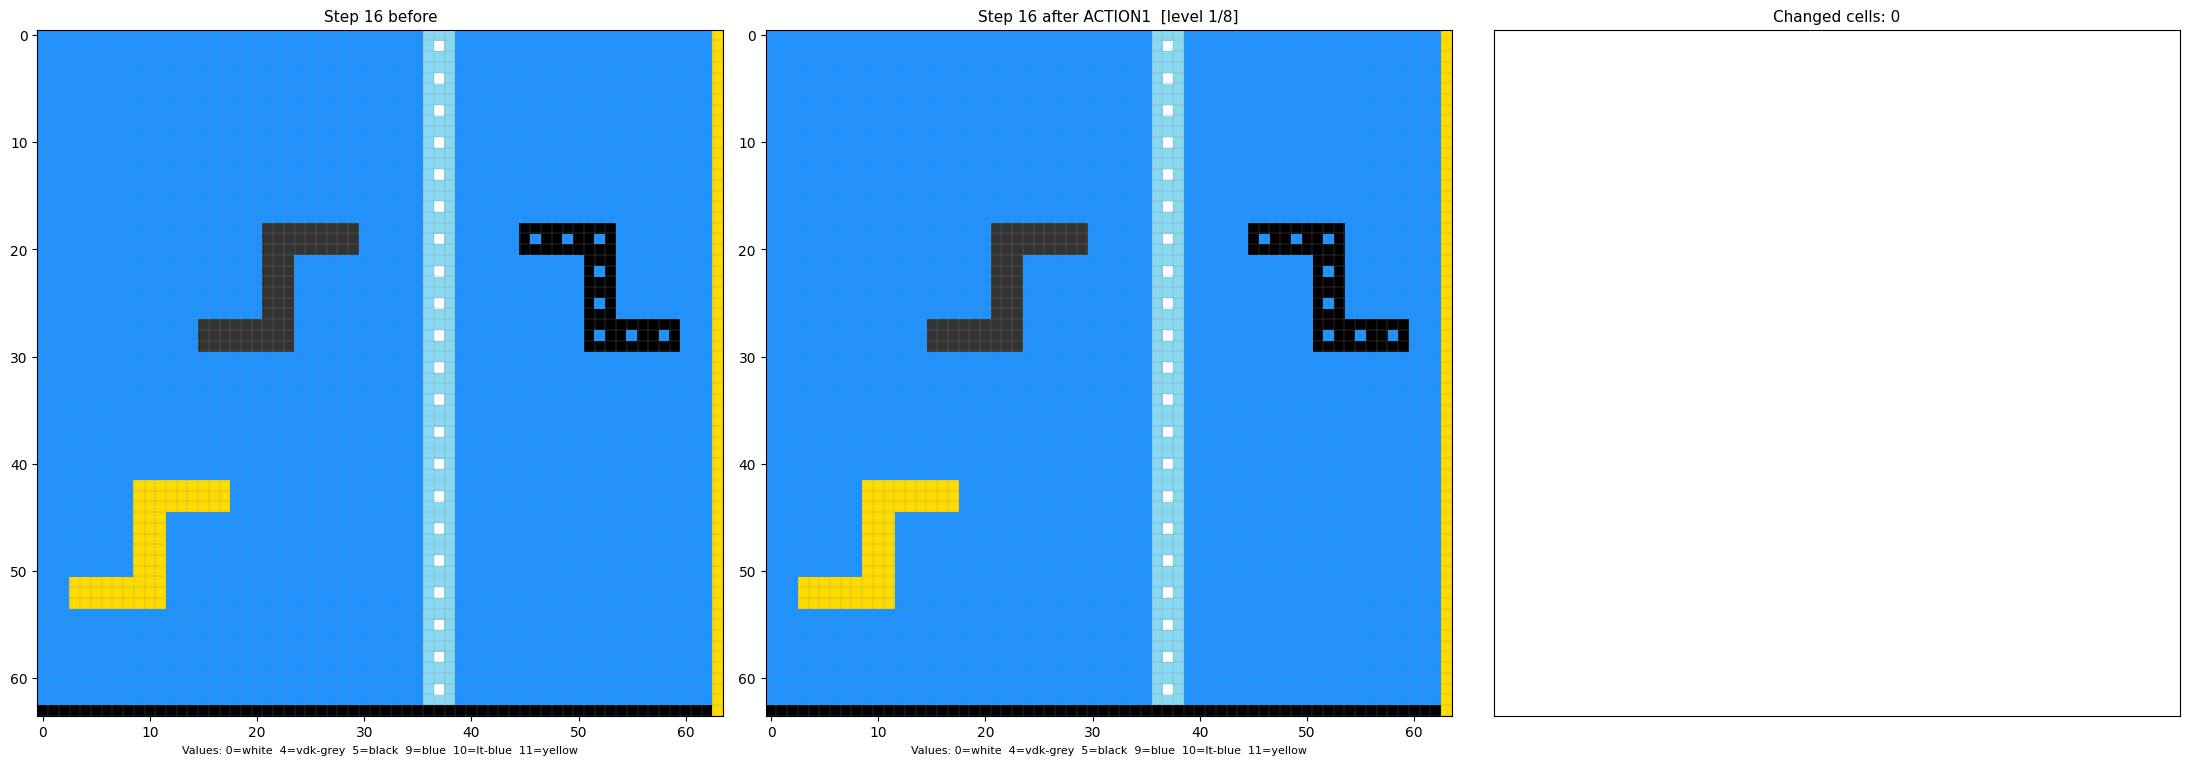

Step 17: ACTION2  →  level 1/8


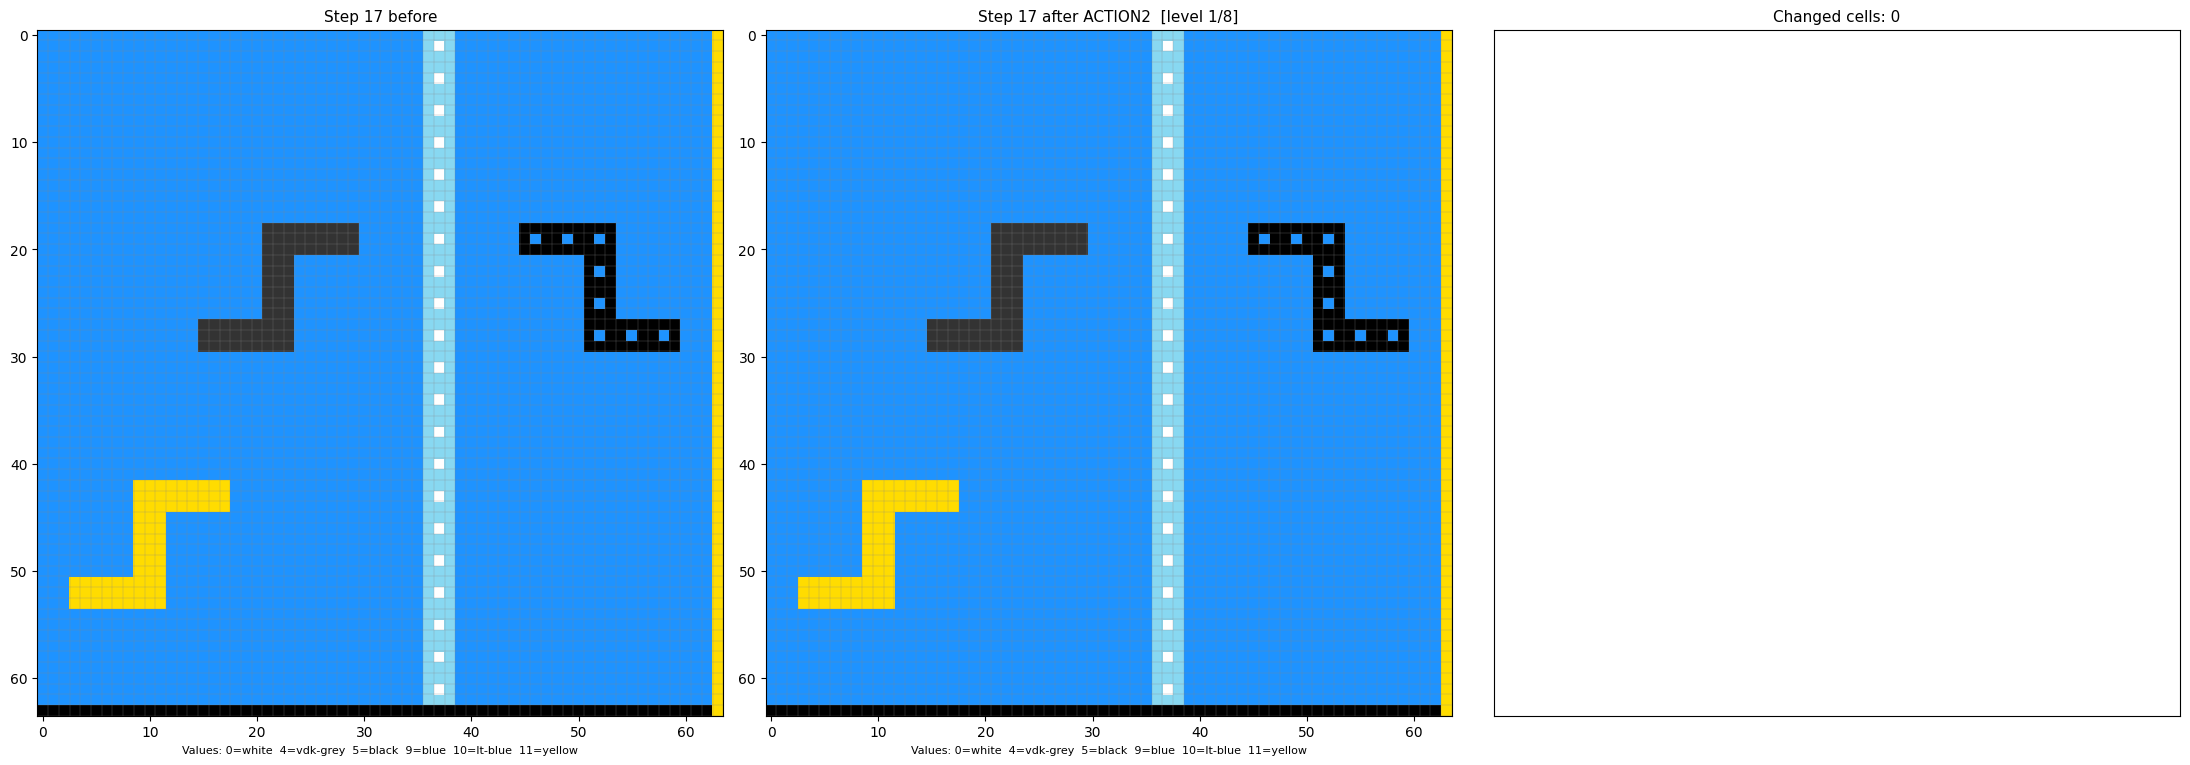

Step 18: ACTION3  →  level 1/8


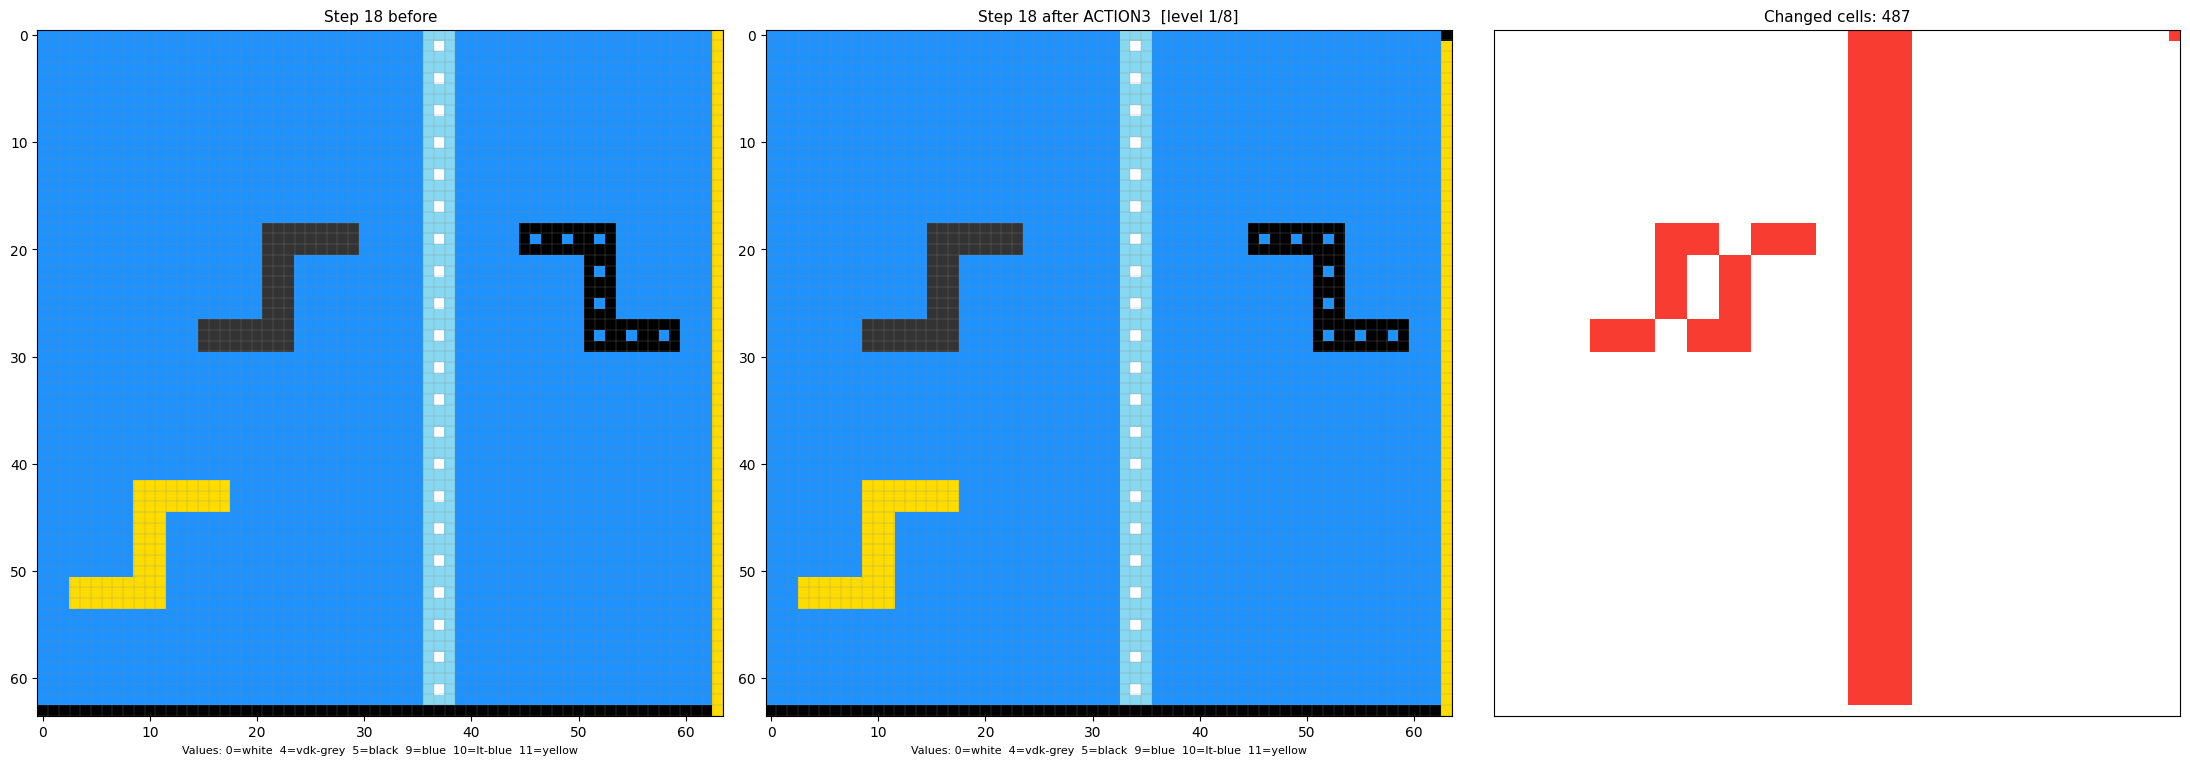


Final: 1/8 levels completed


In [38]:
# ── Cell 7: Step through a sequence — continues from current game state ───────
# Edit ACTIONS and re-run to continue from where you left off.
# Run Cell 4 to reset back to level 1.
ACTIONS = ['2','2','2','2','2','2','3','3','3','3','3','2','2','2','2','1','2','3']

if _env is None or _game_id is None:
    print('Run Cell 2 first.')
else:
    prev_grid = _last_grid
    prev_levels = _last_levels

    print(f'Continuing {_game_id} from level {prev_levels}. Win at {_env.observation_space.win_levels}.')
    print(f'Baseline per level: {_env.info.baseline_actions}\n')

    for i, act_str in enumerate(ACTIONS):
        action = ACTION_NAMES[act_str]
        frame = _env.step(action, data={})
        curr_grid = [row.tolist() for row in frame.frame[-1]]

        completed = frame.levels_completed > prev_levels
        finished = frame.state.name == 'FINISHED'

        if completed:
            # The game transitions atomically: curr_grid is already the next level's
            # initial state. Show the pre-completion state, then the new level start.
            print(f'Step {i+1:2d}: ACTION{act_str}  →  ★ LEVEL {frame.levels_completed} COMPLETE ★')
            show_grid(prev_grid,
                      title=f'★  Level {prev_levels} — COMPLETED  ★  (state before completing action)',
                      figsize=(8, 8))
            if not finished:
                show_grid(curr_grid,
                          title=f'Level {frame.levels_completed} — initial state',
                          figsize=(8, 8))
        else:
            tag = f'level {frame.levels_completed}/{frame.win_levels}'
            print(f'Step {i+1:2d}: ACTION{act_str}  →  {tag}')
            show_diff(prev_grid, curr_grid,
                      title_before=f'Step {i+1} before',
                      title_after=f'Step {i+1} after ACTION{act_str}  [{tag}]')

        prev_grid = curr_grid
        prev_levels = frame.levels_completed

        if finished:
            print('\n★★★  GAME WON!  ★★★')
            break

    # Persist state so the next Cell 7 run continues from here
    _last_grid = prev_grid
    _last_levels = prev_levels

    print(f'\nFinal: {prev_levels}/{frame.win_levels} levels completed')


2026-06-10 14:48:13 | INFO | Found latest version of ar25: ar25-0c556536 (downloaded: 2026-04-08 20:07:48.460282+00:00)
Action table for ar25
Available actions: [1, 2, 3, 4, 5, 6, 7]
Baseline per level: [32, 50, 75, 37, 89, 159, 233, 73]
Win condition: 8 levels



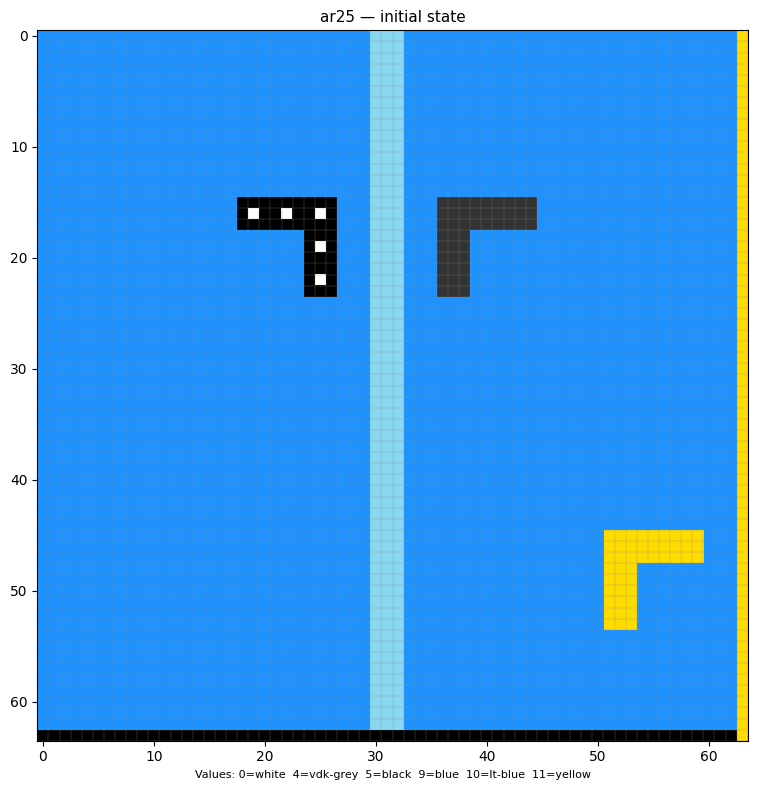

2026-06-10 14:48:13 | INFO | Found latest version of ar25: ar25-0c556536 (downloaded: 2026-04-08 20:07:48.460282+00:00)
ACTION1: white (3 cells) moved up ~5.0 cells  |  vdk-grey (27 cells) moved up ~5.0 cells  |  black: 24 cells lost, 25 cells gained  |  blue (54 cells) moved down ~5.0 cells  |  yellow (1 cells) disappeared from ~(0.0, 63.0)


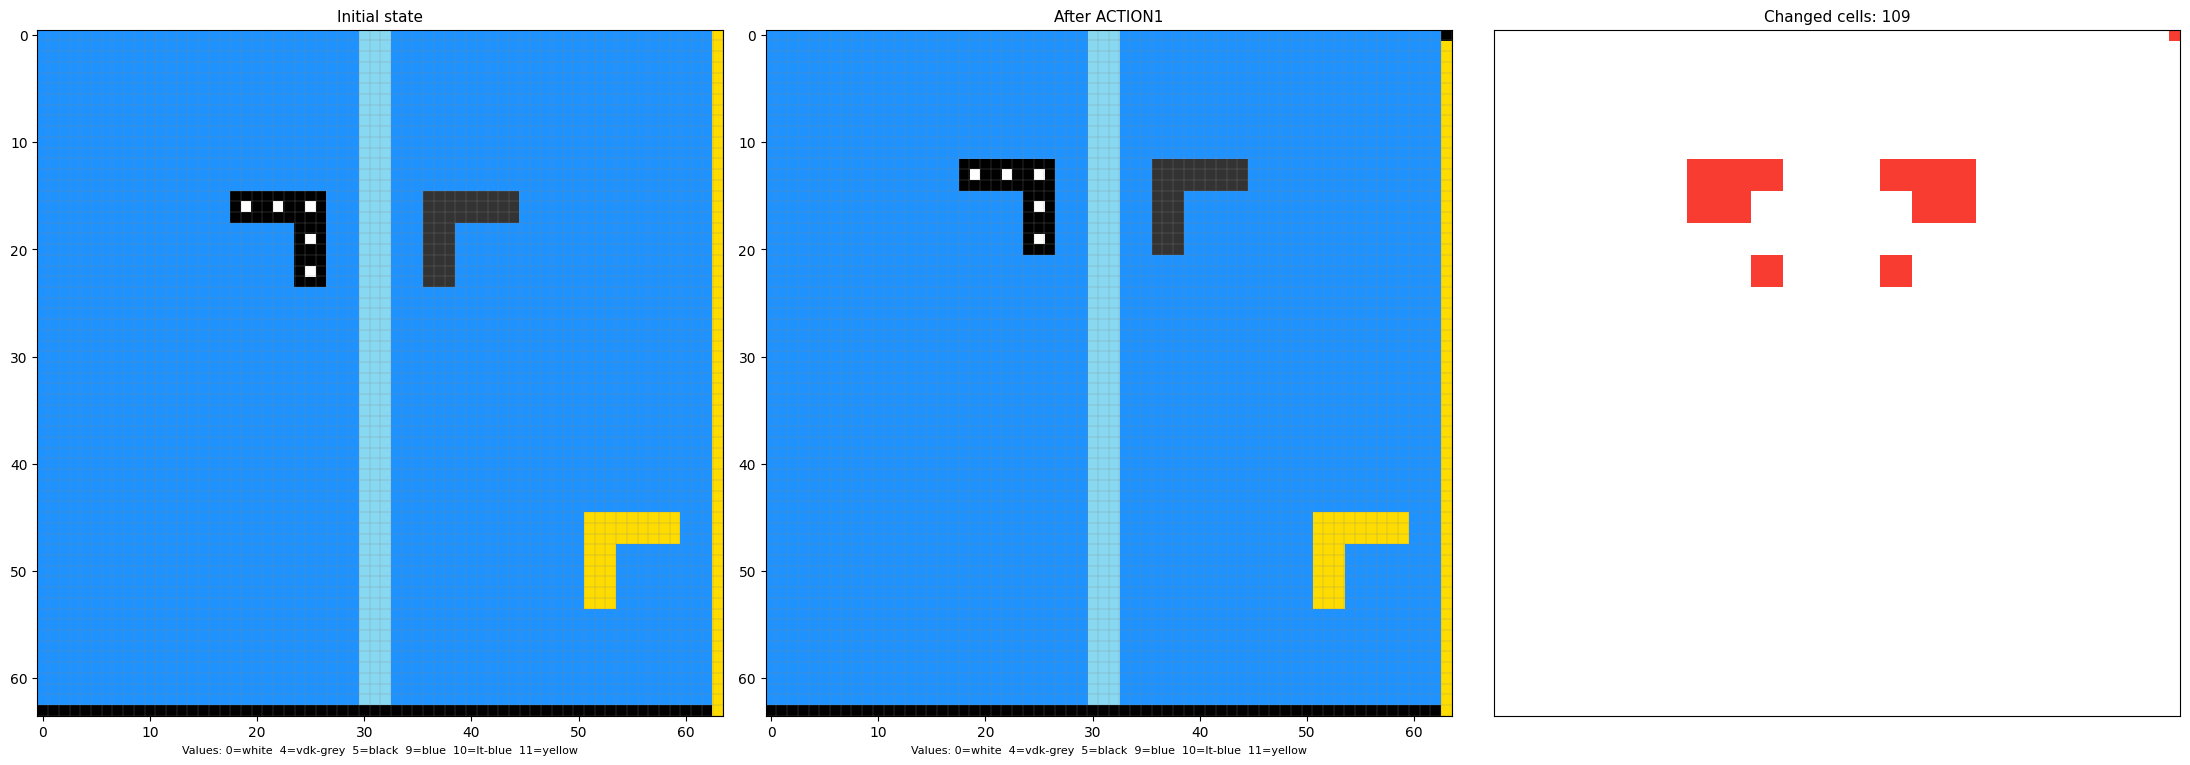

2026-06-10 14:48:14 | INFO | Found latest version of ar25: ar25-0c556536 (downloaded: 2026-04-08 20:07:48.460282+00:00)
ACTION2: white (3 cells) moved down ~5.0 cells  |  vdk-grey (27 cells) moved down ~5.0 cells  |  black: 24 cells lost, 25 cells gained  |  blue (54 cells) moved up ~5.0 cells  |  yellow (1 cells) disappeared from ~(0.0, 63.0)


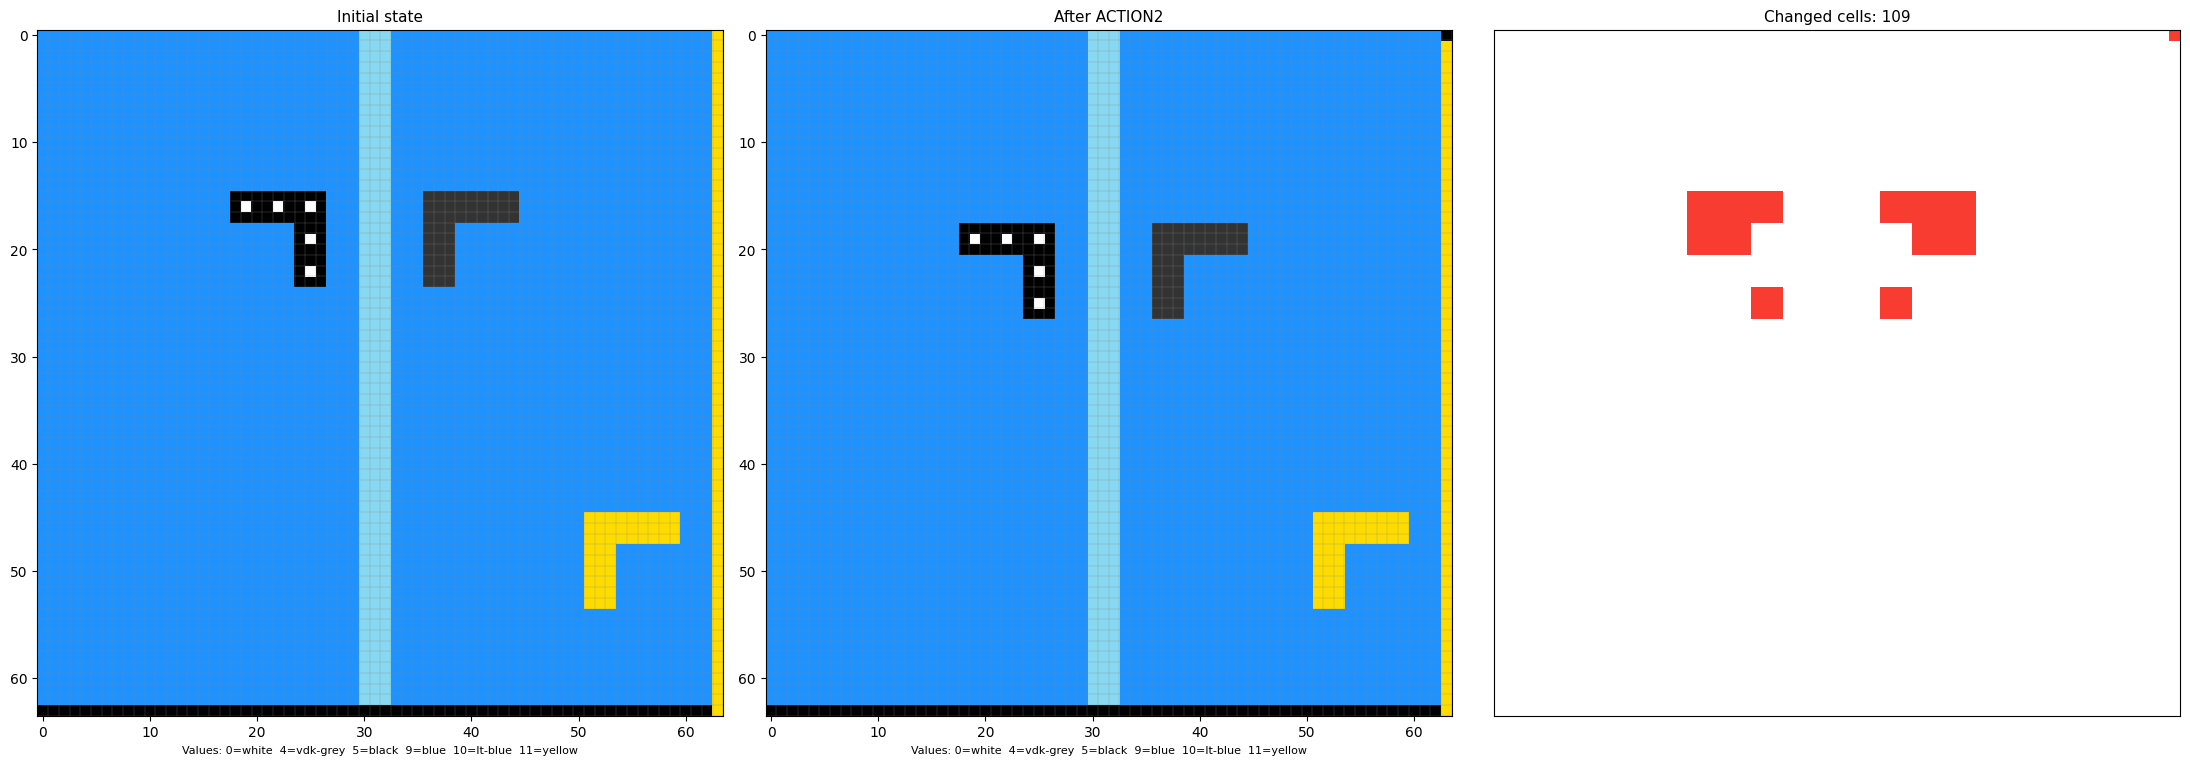

2026-06-10 14:48:14 | INFO | Found latest version of ar25: ar25-0c556536 (downloaded: 2026-04-08 20:07:48.460282+00:00)
ACTION3: white (3 cells) moved left ~5.0 cells  |  vdk-grey (27 cells) moved right ~5.0 cells  |  black: 24 cells lost, 25 cells gained  |  blue (54 cells) moved up ~0.0 cells  |  yellow (1 cells) disappeared from ~(0.0, 63.0)


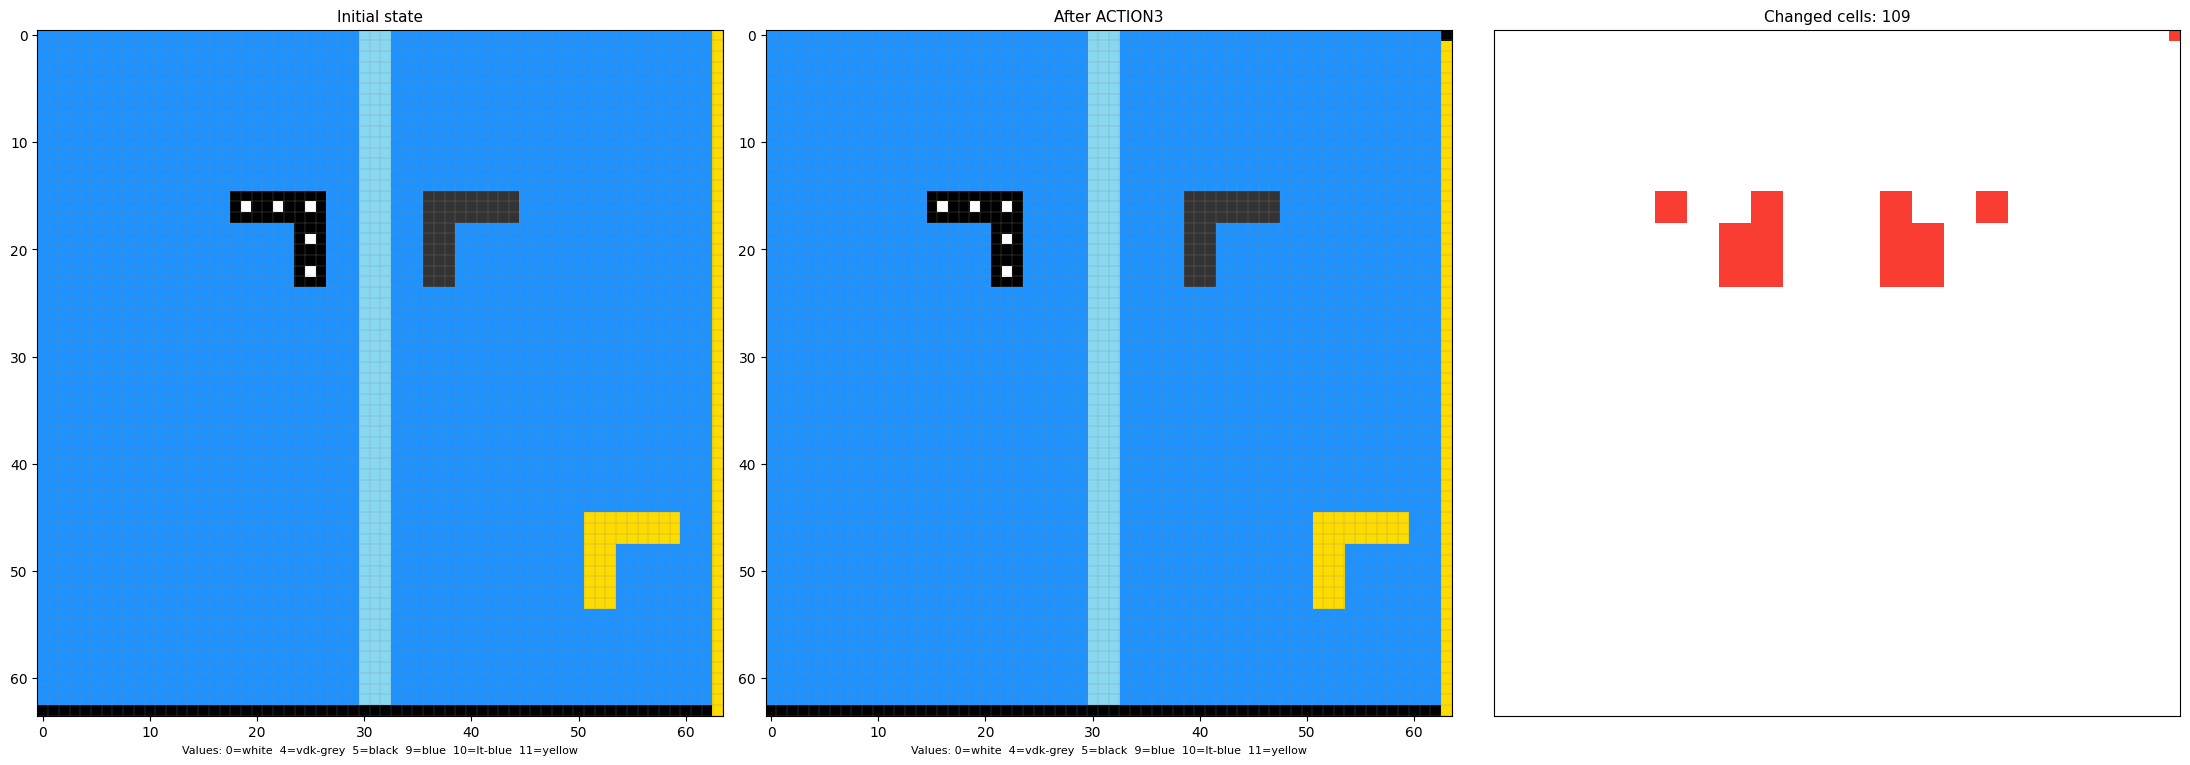

2026-06-10 14:48:14 | INFO | Found latest version of ar25: ar25-0c556536 (downloaded: 2026-04-08 20:07:48.460282+00:00)
ACTION4: white (3 cells) moved right ~5.0 cells  |  vdk-grey (27 cells) moved left ~5.0 cells  |  black: 24 cells lost, 25 cells gained  |  blue (54 cells) moved up ~0.0 cells  |  yellow (1 cells) disappeared from ~(0.0, 63.0)


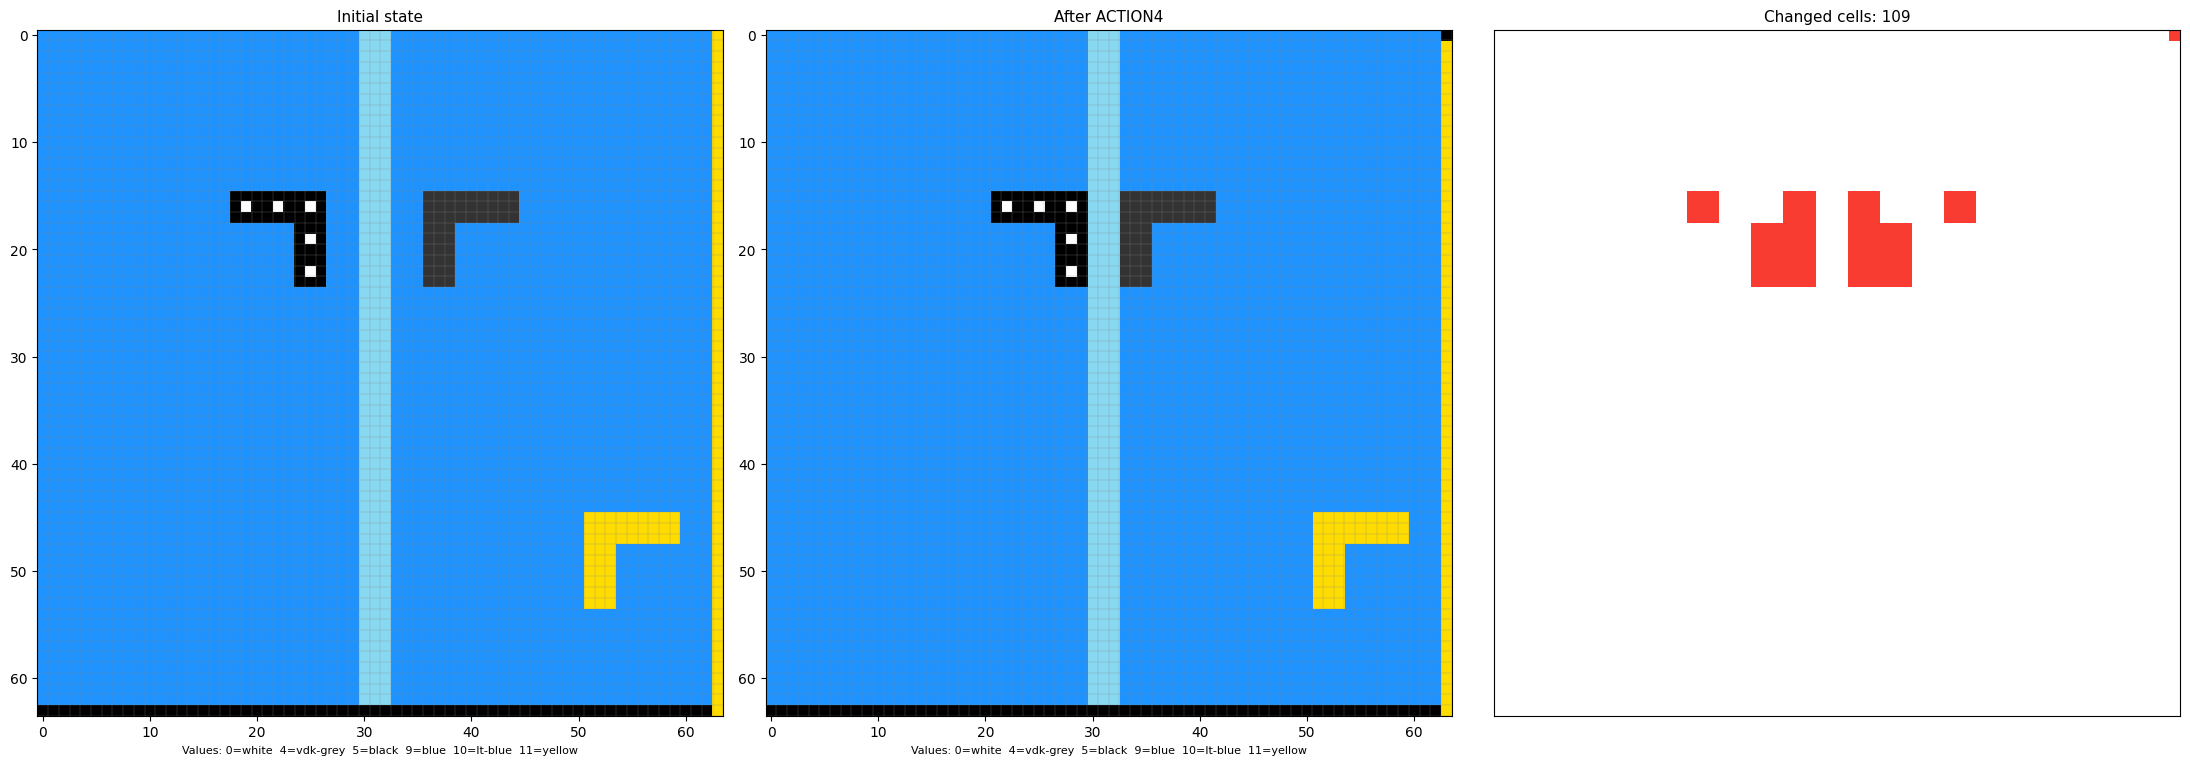

2026-06-10 14:48:15 | INFO | Found latest version of ar25: ar25-0c556536 (downloaded: 2026-04-08 20:07:48.460282+00:00)
ACTION5: black (1 cells) appeared at ~(0.0, 63.0)  |  yellow (1 cells) disappeared from ~(0.0, 63.0)


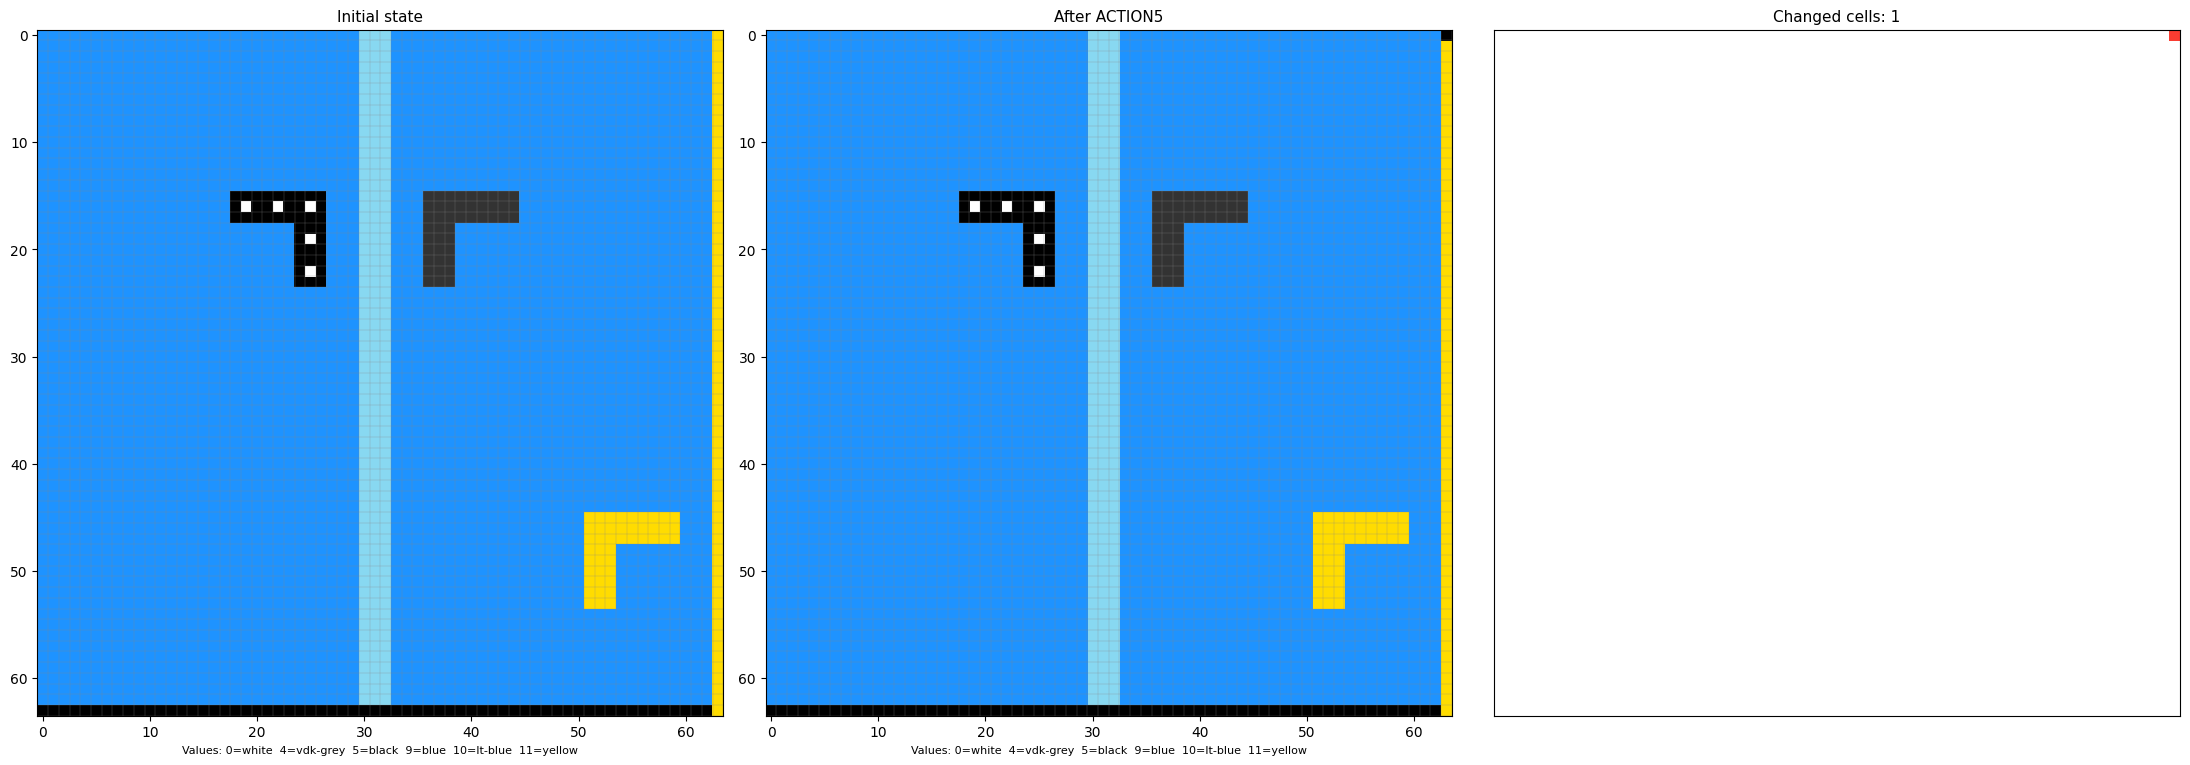

2026-06-10 14:48:15 | INFO | Found latest version of ar25: ar25-0c556536 (downloaded: 2026-04-08 20:07:48.460282+00:00)
ACTION6: no change


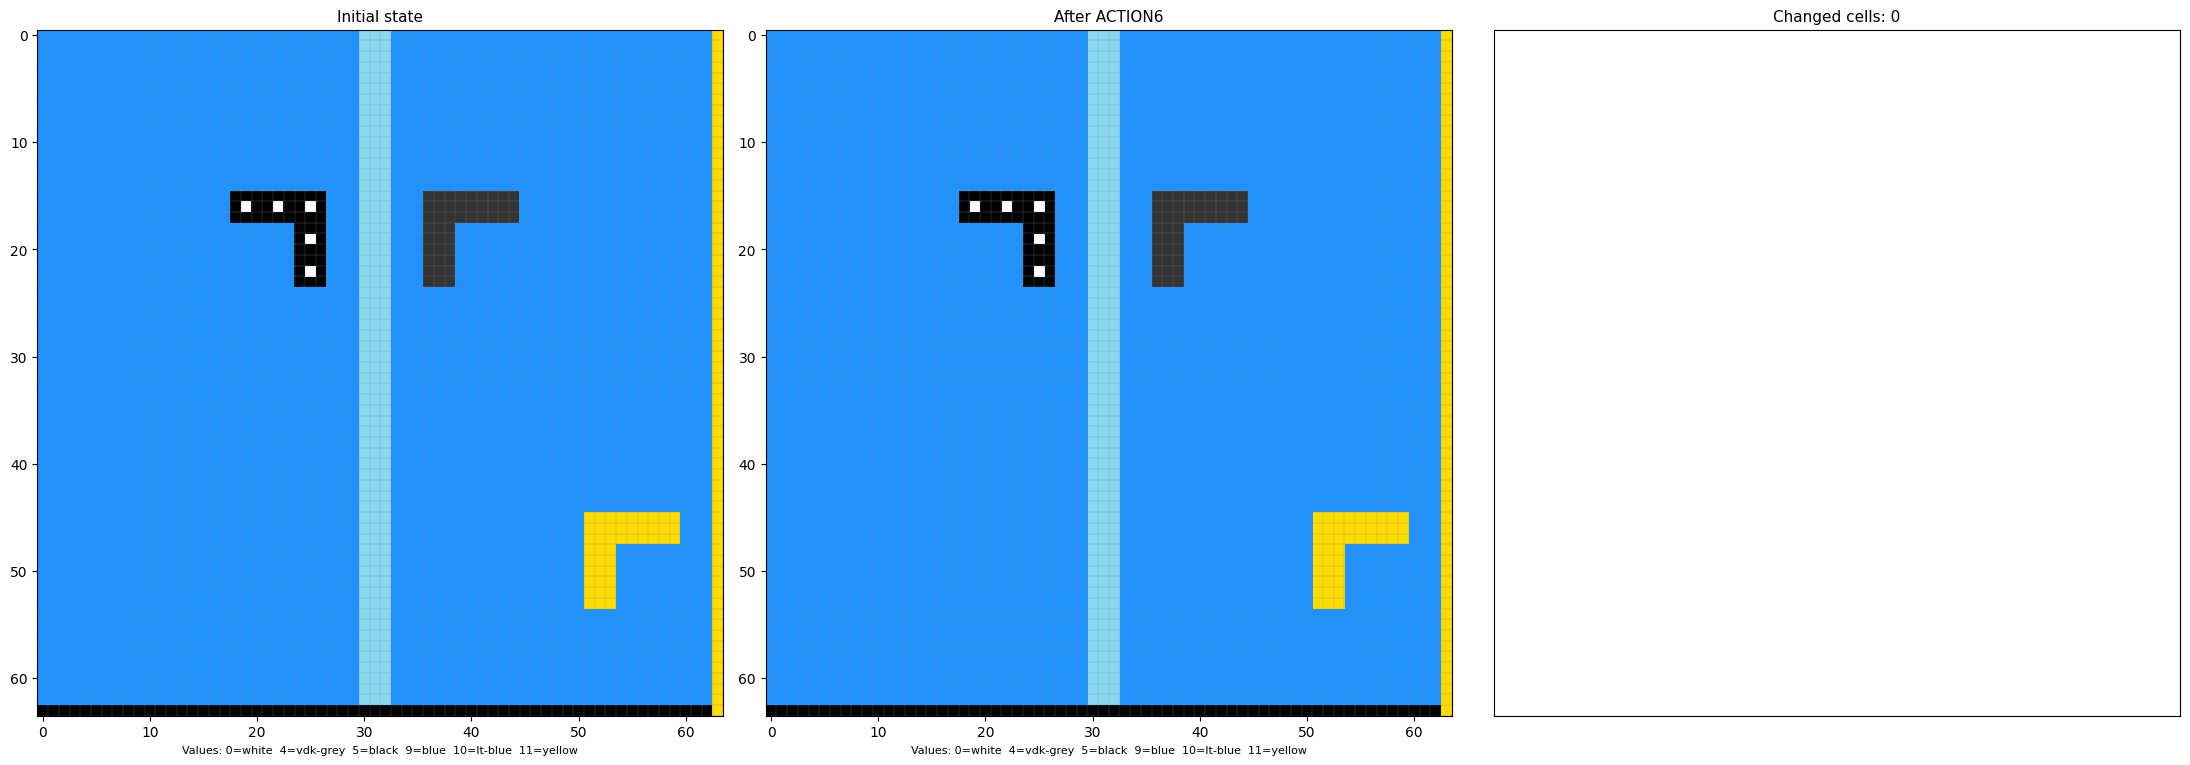

2026-06-10 14:48:15 | INFO | Found latest version of ar25: ar25-0c556536 (downloaded: 2026-04-08 20:07:48.460282+00:00)
ACTION7: no change


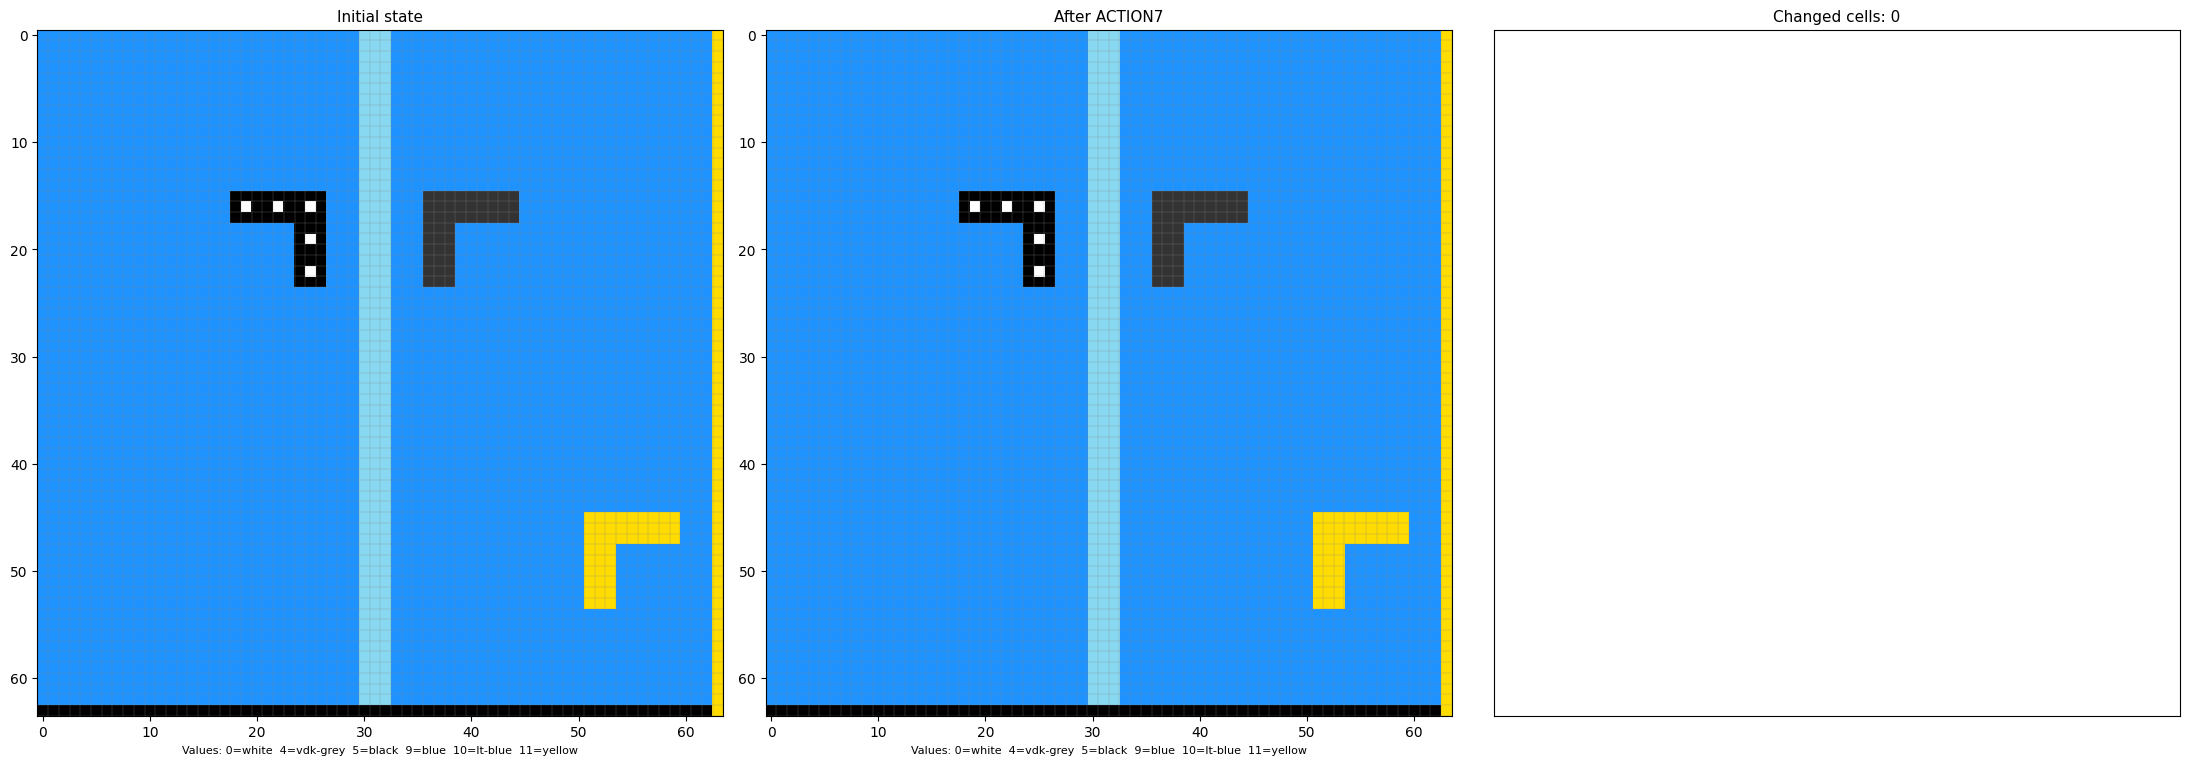


── Object-level summary ─────────────────────────────────────────────
  ACTION1:     white (3 cells) moved up ~5.0 cells
    vdk-grey (27 cells) moved up ~5.0 cells
    black: 24 cells lost, 25 cells gained
    blue (54 cells) moved down ~5.0 cells
    yellow (1 cells) disappeared from ~(0.0, 63.0)
  ACTION2:     white (3 cells) moved down ~5.0 cells
    vdk-grey (27 cells) moved down ~5.0 cells
    black: 24 cells lost, 25 cells gained
    blue (54 cells) moved up ~5.0 cells
    yellow (1 cells) disappeared from ~(0.0, 63.0)
  ACTION3:     white (3 cells) moved left ~5.0 cells
    vdk-grey (27 cells) moved right ~5.0 cells
    black: 24 cells lost, 25 cells gained
    blue (54 cells) moved up ~0.0 cells
    yellow (1 cells) disappeared from ~(0.0, 63.0)
  ACTION4:     white (3 cells) moved right ~5.0 cells
    vdk-grey (27 cells) moved left ~5.0 cells
    black: 24 cells lost, 25 cells gained
    blue (54 cells) moved up ~0.0 cells
    yellow (1 cells) disappeared from ~(0.0, 63.0)
 

In [44]:
# ── Cell 8: Action table — object-level description of each action ────────────
# For each available action: loads a fresh game, takes that one action, then
# describes the effect in object terms (what moved, in which direction, by how
# much) rather than raw cell counts. Resets between each probe.

if _game_id is None:
    print('Run Cell 2 first.')
else:
    import numpy as np
    from collections import deque

    def connected_components(grid, ignore_value=None):
        """Return list of objects: {colour, cells, size, centroid, shape_key}."""
        arr = np.array(grid)
        visited = np.zeros_like(arr, dtype=bool)
        objects = []
        for r in range(arr.shape[0]):
            for c in range(arr.shape[1]):
                v = int(arr[r, c])
                if visited[r, c] or v == ignore_value:
                    continue
                # BFS
                cells = []
                q = deque([(r, c)])
                visited[r, c] = True
                while q:
                    cr, cc = q.popleft()
                    cells.append((cr, cc))
                    for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                        nr, nc = cr+dr, cc+dc
                        if 0 <= nr < arr.shape[0] and 0 <= nc < arr.shape[1]:
                            if not visited[nr, nc] and arr[nr, nc] == v:
                                visited[nr, nc] = True
                                q.append((nr, nc))
                min_r = min(x[0] for x in cells)
                min_c = min(x[1] for x in cells)
                centroid = (sum(x[0] for x in cells)/len(cells),
                            sum(x[1] for x in cells)/len(cells))
                shape_key = frozenset((x[0]-min_r, x[1]-min_c) for x in cells)
                objects.append({
                    'colour': v,
                    'size': len(cells),
                    'centroid': centroid,
                    'shape_key': shape_key,
                    'cells': frozenset(cells),
                })
        return objects

    def describe_changes(before_grid, after_grid):
        """High-level description: what moved, what changed colour, what appeared."""
        a = np.array(before_grid)
        b = np.array(after_grid)
        diff = (a != b)
        if not diff.any():
            return ['no change']

        descriptions = []
        all_colours = sorted(set(a[diff].tolist()) | set(b[diff].tolist()))

        for colour in all_colours:
            lost  = diff & (a == colour)
            gained = diff & (b == colour)
            n_lost   = int(lost.sum())
            n_gained = int(gained.sum())

            name = ARC3_NAMES[colour]

            if n_lost > 0 and n_gained > 0 and n_lost == n_gained:
                # Same count: likely a pure translation — use centroid shift
                lr, lc = np.where(lost)
                gr, gc = np.where(gained)
                dr = float(np.mean(gr) - np.mean(lr))
                dc = float(np.mean(gc) - np.mean(lc))
                if abs(dr) >= abs(dc):
                    direction = 'down' if dr > 0 else 'up'
                    dist = abs(dr)
                else:
                    direction = 'right' if dc > 0 else 'left'
                    dist = abs(dc)
                descriptions.append(
                    f'{name} ({n_lost} cells) moved {direction} ~{dist:.1f} cells'
                )
            elif n_lost > 0 and n_gained == 0:
                lr, lc = np.where(lost)
                centroid = (float(np.mean(lr)), float(np.mean(lc)))
                descriptions.append(
                    f'{name} ({n_lost} cells) disappeared from ~{centroid}'
                )
            elif n_gained > 0 and n_lost == 0:
                gr, gc = np.where(gained)
                centroid = (float(np.mean(gr)), float(np.mean(gc)))
                descriptions.append(
                    f'{name} ({n_gained} cells) appeared at ~{centroid}'
                )
            else:
                descriptions.append(
                    f'{name}: {n_lost} cells lost, {n_gained} cells gained'
                )
        return descriptions

    # ── probe each action ──────────────────────────────────────────────────────
    env0 = _arcade.make(_game_id)
    obs0 = env0.observation_space
    initial_grid = [row.tolist() for row in obs0.frame[-1]]
    available = obs0.available_actions

    print(f'Action table for {_game_id}')
    print(f'Available actions: {available}')
    print(f'Baseline per level: {env0.info.baseline_actions}')
    print(f'Win condition: {obs0.win_levels} levels\n')

    # Show initial state once
    show_grid(initial_grid, title=f'{_game_id} — initial state', figsize=(8, 8))

    summary = []
    for act_id in available:
        env_probe = _arcade.make(_game_id)
        frame = env_probe.step(ACTION_NAMES[str(act_id)], data={})
        probe_grid = [row.tolist() for row in frame.frame[-1]]
        descs = describe_changes(initial_grid, probe_grid)
        summary.append((act_id, descs))
        label = '  |  '.join(descs)
        print(f'ACTION{act_id}: {label}')
        show_diff(initial_grid, probe_grid,
                  title_before='Initial state',
                  title_after=f'After ACTION{act_id}')

    print('\n── Object-level summary ─────────────────────────────────────────────')
    for act_id, descs in summary:
        print(f'  ACTION{act_id}: {chr(10).join("    " + d for d in descs)}')
